# **Phenotypic Bias in Heart Disease Prediction**
### *Fairness, Explainability, and Data-Centric Analysis of the Cleveland Dataset*

**Author:** Francisca Mihalache  
**Course:** Artificial Intelligence and Society — Individual Assignment  

## **1. Introduction and Context**

The deployment of Artificial Intelligence (AI) in high-stakes domains, particularly healthcare, necessitates a rigorous evaluation of **trustworthiness**, moving beyond simple performance metrics such as accuracy. Under the **EU AI Act**, medical diagnostic tools are classified as **High-Risk AI Systems**, requiring strict adherence to data governance, transparency, and human oversight. This study investigates the reliability of heart disease prediction models through the lens of **Responsible AI**, focusing on the tension between aggregate performance and subgroup fairness.

### **1.1. Theoretical Framework**

This analysis adopts a **Data-Centric AI (DC-AI)** perspective, positing that model failures often stem from data intrinsic characteristics (such as noise, overlap, and sparsity) rather than algorithmic deficiencies. We move away from the "Big Data" paradigm towards **"Smart Data"**, prioritizing data quality and representativeness over volume.

Specifically, we address **phenotypic bias**, a form of **representation bias** where certain clinical presentations (phenotypes) are underrepresented in the training data. In cardiovascular medicine, this often manifests as **within-class imbalance** (or *small disjuncts*), where minority subgroups (e.g., women with non-anginal pain) form sparse clusters within the class distribution, making them harder for standard classifiers to learn.

### **1.2. Methodology**

The study is structured around three pillars of trustworthy AI:

1. **Data Profiling & Complexity Analysis:** We perform a systematic audit of the **UCI Heart Disease (Cleveland)** dataset to identify **data quality issues** and **intrinsic complexity factors** such as class overlap and imbalance.
2. **Fairness Assessment:** We evaluate **Group Fairness** metrics, specifically focusing on **Equality of Opportunity** (Equalized Odds), to determine if the model's error rates (False Negatives/Positives) are distributed equitably across biological sex and chest pain types. We also investigate the "Fairness through Unawareness" fallacy by analyzing whether removing sensitive attributes eliminates bias or merely shifts reliance to **proxies**.
3. **Explainability (XAI):** Utilizing **SHAP (SHapley Additive Exlanations)**, we decompose model predictions into the **marginal contributions** of each feature. This allows us to verify whether the model relies on robust physiological markers or exploits demographic biases, thereby ensuring the **transparency** required by regulatory frameworks.
---
## **Table of Contents**

1. [Dataset Background and Structure](#1-dataset-background-and-structure)
    * 1.1 [Dataset Loading and Description](#11-dataset-loading-and-description)
    * 1.2 [Variable Definitions](#12-variable-definitions)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis-eda)
    * 2.1 [General Information](#21-general-information)
    * 2.2 [Missing Values](#22-missing-values)
    * 2.3 [Chest Pain Type Distribution (cp)](#23-chest-pain-type-distribution-cp)
    * 2.4 [Chest Pain Type vs. Sex](#24-chest-pain-type-vs-sex)
    * 2.5 [Age Distribution by Sex](#25-age-distribution-by-sex)
    * 2.6 [Correlation Matrix](#26-correlation-matrix-numeric-variables)
    * 2.7 [Pairplot Analysis](#27-pairplot)
    * 2.8 [Missing Data Heatmap](#28-missing-data-heatmap)
    * 2.9 [Feature Distributions by Disease Status](#29-feature-distributions-by-disease-status)
    * 2.10 [Prevalence by Chest Pain Type](#210-heart-disease-prevalence-by-chest-pain-type)
    * 2.11 [Physiological Interactions (ECG, BP, Heart Rate)](#213-age-vs-maximum-heart-rate-thalach)
3. [Data Preprocessing](#3-data-preprocessing)
    * 3.1 [Handling Missing Values](#31-handling-missing-values)
    * 3.2 [Target Variable Transformation](#32-target-variable-transformation)
    * 3.3 [Feature Encoding & Scaling](#33-feature-encoding)
4. [Model Training and Selection](#4-model-training)
    * 4.1 [Data Splitting Strategy](#41-data-splitting-train--validation--test)
    * 4.2 [Model Comparison (LR, RF, XGBoost, MLP)](#42-model-selection-and-training)
    * 4.3 [Performance and Fairness Analysis](#43-performance-and-fairness-analysis)
        * 4.3.1 [Global Performance & Cross-Validation](#431-global-model-performance)
        * 4.3.2 [Gender-Specific Performance Analysis](#432-gender-specific-performance-analysis)
        * 4.3.3 [Chest-Pain–Specific Performance Analysis](#433-chest-pain-specific-performance-analysis)
        * 4.3.4 [Intersection: Chest Pain × Sex](#434-interaction-chest-pain--sex-performance-analysis)
    * 4.4 [SHAP-Based Explainability](#44-shap-based-explainability)
        * 4.4.1 [Global Feature Importance](#441-global-shap)
        * 4.4.2 [SHAP by Gender](#442-shap-by-gender)
        * 4.4.3 [SHAP by Chest Pain Type](#443-shap-by-chest-pain-type)
        * 4.4.4 [Local Explanations (Waterfall Plots)](#444-local-explanations)
5. [Bias Mitigation & Fairness Audit](#5-bias-mitigation--fairness-audit)
    * 5.1 [Safety-First Model Optimization (F2-Score)](#51-safety-first-model-optimization-f2-score)
    * 5.2 [Phenotypic Refinement via Dynamic Thresholding](#52-phenotypic-refinement-via-dynamic-thresholding)
    * 5.3 [Structural Mitigation: Decoupled Classifiers](#53-structural-mitigation-decoupled-classifiers)
    * 5.4 [Fairness Audit (Miss-Rate Analysis)](#54-fairness-audit-miss-rate-analysis)
    * 5.5 [Trade-Off Analysis (Male Subgroup)](#55-trade-off-analysis-male-subgroup)
6. [Mechanism of Bias (Data Scarcity vs. Physiology)](#6-mechanism-of-bias-data-scarcity-vs-physiology)
    * 6.1 [Targeted Oversampling (Counterfactual Experiment)](#61-targeted-oversampling-counterfactual-experiment)

7. [Ethical Reflection and Discussion](#6-ethical-reflection-and-discussion)
    * 7.1 [Phenotypic and Gender Bias](#61-phenotypic-and-gender-bias-in-heart-disease-prediction)
    * 7.2 [Potential Harms and Societal Impact](#62-potential-harms-and-societal-impact)
    * 7.3 [EU AI Act & Regulatory Classification](#63-eu-ai-act--regulatory-classification)
    * 7.4 [Responsible AI Practices](#64-responsible-ai-practices-implemented-in-this-study)
    * 7.5 [Ethical Gaps and Recommendations](#65-remaining-gaps-and-ethical-recommendations)
8. [References](#7-references)

#### Environment Setup


In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


#### Imports

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, log_loss, classification_report, 
    confusion_matrix
)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from ucimlrepo import fetch_ucirepo 
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import pandas as pd
import missingno as msno
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (recall_score, accuracy_score, precision_score, 
                             f1_score, fbeta_score, make_scorer, 
                             confusion_matrix, precision_recall_curve, auc)

print("Libraries loaded. Starting mitigation pipeline...")

Libraries loaded. Starting mitigation pipeline...


<a id="1"></a>
## 1. Dataset Background and Structure



#### 1.1 Dataset Loading and Description
We fetch the UCI Heart Disease (Cleveland) dataset using the ucimlrepo package.
The dataset includes 303 patients and 13 clinical features related to cardiovascular risk.

In [3]:
# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

# Data as pandas DataFrames
X = heart_disease.data.features
y = heart_disease.data.targets

# Display concise metadata
meta_df = pd.DataFrame(list(heart_disease.metadata.items()), columns=["Key", "Value"])
display(meta_df)  

# Display only first 10 variable descriptions
display(heart_disease.variables)

,Key,Value
0,uci_id,45
1,name,Heart Disease
2,repository_url,https://archive.ics.uci.edu/dataset/45/heart+d...
3,data_url,https://archive.ics.uci.edu/static/public/45/d...
4,abstract,"4 databases: Cleveland, Hungary, Switzerland, ..."
5,area,Health and Medicine
6,tasks,[Classification]
7,characteristics,[Multivariate]
8,num_instances,303
9,num_features,13


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


The tables above summarize the **dataset metadata** and the **full list of variables** retrieved from the UCI Machine Learning Repository.  
The original code example from the `ucimlrepo` documentation was slightly modified to present the information in a more compact and structured way.

From the **metadata table**, we confirm that:

- **Task type:** Classification (predicting presence of heart disease)  
- **Instances:** 303 patients  
- **Features:** 13 clinical attributes (a mix of categorical, integer, and real types)  
- **Demographic variables:** Age and Sex  
- **Target variable:** `num` — ranges from 0 (no disease) to 4 (presence of disease)  
- **Missing values:** Yes — represented as `NaN`  
- **Dataset creation year:** 1989, updated in 2023  
- **Creators:** Andras Janosi, William Steinbrunn, Matthias Pfisterer, Robert Detrano  
- **DOI:** [10.24432/C52P4X](https://doi.org/10.24432/C52P4X)  
- **Repository link:** [UCI Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)

From the **variable table**, we can summarize:
- There are 13 input features (`age`, `sex`, `cp`, `trestbps`, `chol`, `fbs`, `restecg`, `thalach`, `exang`, `oldpeak`, `slope`, `ca`, `thal`) and 1 target variable (`num`).  
- Most features are either **integer** or **categorical**, aligning with clinical measurements and diagnostic categories.  
- The `cp` (chest pain type) variable is especially important for this project — it differentiates patients by pain presentation (*typical angina*, *atypical angina*, *non-anginal pain*, *asymptomatic*) and will be used to study *phenotypic bias*.  
- The variables `ca` (number of major vessels) and `thal` contain missing values.  
- Descriptive units include `mm Hg` (for blood pressure) and `mg/dl` (for cholesterol).  

This metadata inspection confirms that the dataset is well-suited for the intended analysis on **fairness** and **explainability**.  

Next, we proceed to **data preprocessing**, where the target variable will be binarized and missing values will be handled before training the classification models.


### 1.2 Variable Definitions

According to the official documentation provided by the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease), the Heart Disease (Cleveland) dataset includes **14 clinical attributes** originally described by *Detrano et al. (1989)* in the *American Journal of Cardiology*.  

The variable definitions are summarized below and will be considered throughout this study for proper interpretation and clinical consistency.

| Feature | Description | Type / Units | Encoded Values |
|----------|--------------|---------------|----------------|
| **age** | Age of the patient | Integer / years | — |
| **sex** | Biological sex | Categorical | 1 = male, 0 = female |
| **cp** | Chest pain type | Categorical | 1 = typical angina<br>2 = atypical angina<br>3 = non-anginal pain<br>4 = asymptomatic |
| **trestbps** | Resting blood pressure (on hospital admission) | Integer / mm Hg | — |
| **chol** | Serum cholesterol level | Integer / mg/dl | — |
| **fbs** | Fasting blood sugar > 120 mg/dl | Categorical | 1 = true, 0 = false |
| **restecg** | Resting electrocardiographic results | Categorical | 0 = normal<br>1 = ST–T abnormality<br>2 = left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved | Integer / bpm | — |
| **exang** | Exercise-induced angina | Categorical | 1 = yes, 0 = no |
| **oldpeak** | ST depression induced by exercise relative to rest | Float | — |
| **slope** | Slope of the peak exercise ST segment | Categorical | 1 = upsloping<br>2 = flat<br>3 = downsloping |
| **ca** | Number of major vessels colored by fluoroscopy | Integer (0–3) | — |
| **thal** | Thalassemia | Categorical | 3 = normal<br>6 = fixed defect<br>7 = reversible defect |
| **num** | Diagnosis of heart disease (angiographic disease status) | **Target variable** | 0 = no disease (< 50 % narrowing)<br>1–4 = disease present (> 50 % narrowing) |

These definitions form the foundation of all subsequent analyses.  
They ensure that feature interpretations and clinical reasoning remain consistent with the original dataset documentation and medical context.


## 2. Exploratory Data Analysis (EDA)

After loading and describing the dataset, we now explore its main statistical properties and internal patterns to better understand how the features are distributed.

#### 2.1. General Information

In [4]:
X.info()

# Quick view of numeric variables
X.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


The dataset consists of **303 patient records** and **13 measurable features** related to cardiovascular health.  
All variables are numeric, meaning that categorical features (such as `sex`, `cp`, `restecg`, and `slope`) are encoded as integers.  
This numeric representation simplifies model training but requires semantic remapping later for clearer interpretation.  

Two variables, `ca` (number of major vessels) and `thal` (thalassemia type), contain a small number of missing values.  
These missing entries will be imputed before training to ensure data consistency.  

At this point, the dataset appears well-structured and suitable for the upcoming analyses.  
The next steps will focus on exploring distributions, feature relationships, and possible data imbalances that may affect fairness across patient subgroups.


#### 2.2. Missing Values

In [5]:
# Check for missing data
missing_summary = X.isna().sum()
missing_summary[missing_summary > 0]

ca      4
thal    2
dtype: int64

As confirmed earlier in the variable table, only two features contain missing values: `ca` (number of major vessels) with **4 missing entries**, and `thal` (thalassemia type) with **2 missing entries**.  The number of missing values is very small compared to the dataset size, so these can be safely imputed later without affecting the statistical integrity of the data.


=== Heart Disease Case Distribution ===
0 (No disease):  164 patients
1 (Has disease): 139 patients
Total:            303 patients


/var/folders/4r/r9zph8bx1sg2m5vrr7yly1zh0000gn/T/ipykernel_63117/3419697989.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_binary, palette=['#1f77b4', '#ff7f0e'])


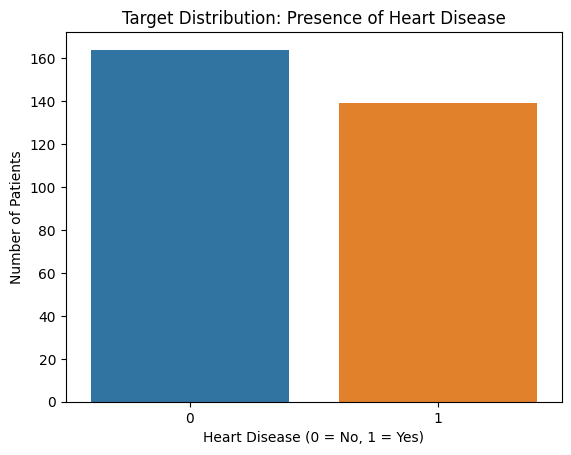

In [6]:
# Convert the target variable to binary: 0 = No disease, 1 = Disease present
y_binary = y['num'].apply(lambda v: 1 if v > 0 else 0)

# Count the number of patients in each class
class_counts = y_binary.value_counts().sort_index()

# Print the class distribution
print("=== Heart Disease Case Distribution ===")
print(f"0 (No disease):  {class_counts[0]} patients")
print(f"1 (Has disease): {class_counts[1]} patients")
print(f"Total:            {class_counts.sum()} patients")

# Visualize the distribution
sns.countplot(x=y_binary, palette=['#1f77b4', '#ff7f0e'])
plt.title('Target Distribution: Presence of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()


This near-balanced distribution (54% vs. 46%) indicates that class imbalance is minimal, allowing models to be trained and evaluated without requiring rebalancing techniques.  

In this context, techniques such as **SMOTE** or other oversampling methods are unnecessary and could even introduce artificial patterns not grounded in clinical reality.  
Following the *Data-Centric AI* rationale, data balance should be evaluated in relation to its **semantic validity** rather than applied mechanically.  
Since the Cleveland dataset already maintains a near-balanced distribution between healthy and diseased cases, preserving its natural proportions ensures more **faithful and interpretable** model behavior.


#### 2.3. Chest Pain Type Distribution (cp)

Here we examine how the four **chest pain types (`cp`)** are distributed across the dataset.  
This helps identify possible **phenotypic imbalance**, for example, whether some clinical presentations are much more common than others, which could later influence model fairness.

/var/folders/4r/r9zph8bx1sg2m5vrr7yly1zh0000gn/T/ipykernel_63117/3629482187.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cp_label', data=X, order=cp_mapping.values(), palette='Set2')


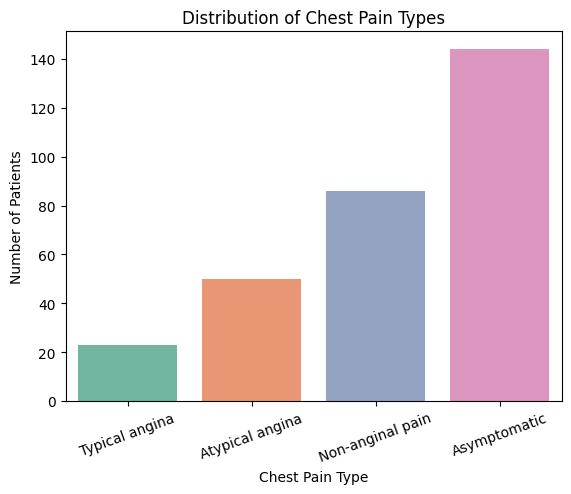

Chest Pain Type Counts:
cp_label
Asymptomatic        144
Non-anginal pain     86
Atypical angina      50
Typical angina       23
Name: count, dtype: int64


In [7]:
# Map chest pain codes to labels
cp_mapping = {1: 'Typical angina', 2: 'Atypical angina', 3: 'Non-anginal pain', 4: 'Asymptomatic'}
X['cp_label'] = X['cp'].map(cp_mapping)

# Plot distribution of chest pain types
sns.countplot(x='cp_label', data=X, order=cp_mapping.values(), palette='Set2')
plt.title('Distribution of Chest Pain Types')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=20)
plt.show()

# Print exact counts
print("Chest Pain Type Counts:")
print(X['cp_label'].value_counts())


The counts show that most patients are **asymptomatic (144)**, followed by **non-anginal pain (86)**,  
while **typical angina (23)** is the least frequent.  
This uneven distribution confirms the presence of **phenotypic imbalance**, meaning that models trained on this dataset may learn patterns dominated by asymptomatic and non-anginal cases.

The four chest pain categories used in the Cleveland dataset follow the clinical definitions adopted by Detrano et al. (1989):
typical angina, atypical angina, non-anginal pain, and asymptomatic.
This classification was a key clinical variable in the original study, as chest pain presentation was one of the most informative predictors of coronary artery disease.
However, Detrano et al. noted that even asymptomatic and non-anginal patients could show significant angiographic abnormalities, revealing potential diagnostic bias when relying only on symptoms

#### 2.4. Chest Pain Type vs. Sex

This table compares **chest pain types (`cp`)** between **male** and **female** patients.  
By observing these distributions, we can check whether certain pain types are more frequent in one sex — a relevant factor in understanding possible **gender-related diagnostic bias**.


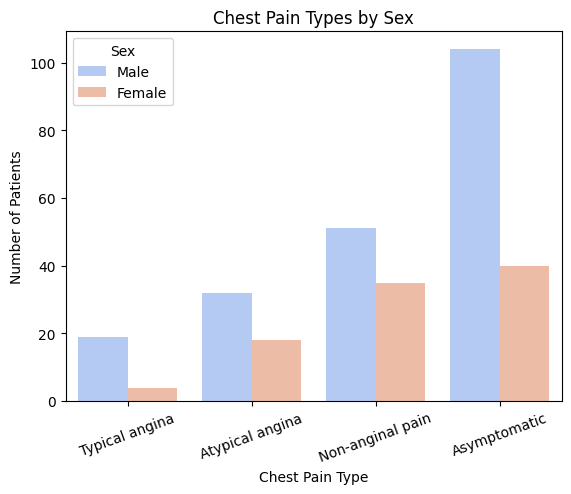

sex_label,Female,Male
cp_label,,
Asymptomatic,40,104
Atypical angina,18,32
Non-anginal pain,35,51
Typical angina,4,19


In [8]:
# Replace sex with readable labels
X['sex_label'] = X['sex'].map({0: 'Female', 1: 'Male'})

# Cross-tab and plot
sns.countplot(data=X, x='cp_label', hue='sex_label', order=cp_mapping.values(), palette='coolwarm')
plt.title('Chest Pain Types by Sex')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.legend(title='Sex')
plt.xticks(rotation=20)
plt.show()

# Print counts
pd.crosstab(X['cp_label'], X['sex_label'])


#### 2.4.1. Chest Pain Type vs. Sex -- Normalized between genders

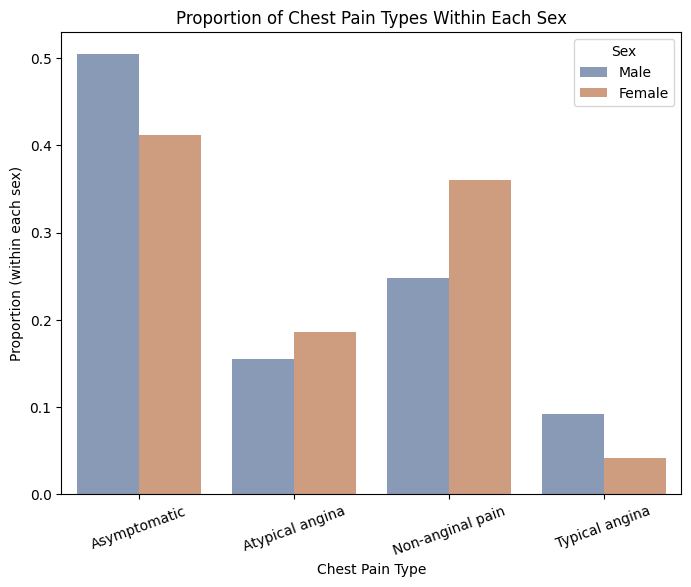

In [9]:
# Create readable labels for sex variable
X['sex_label'] = X['sex'].map({0: 'Female', 1: 'Male'})

# Build a contingency table (absolute counts)
# Rows = sex, Columns = chest pain type (cp)
table = pd.crosstab(X['sex_label'], X['cp_label'])

# Convert absolute counts into proportions within each sex
# This removes the effect of having more males than females in the dataset
prop_df = table.div(table.sum(axis=1), axis=0)

# Convert table to long format for seaborn visualization
prop_df = prop_df.reset_index().melt(
    id_vars='sex_label',
    var_name='cp_label',
    value_name='proportion'
)

# Define custom colors to try to match previous plots-- I didn't find the exact colors used before
colors = {'Male': "#8198BF", 'Female': "#DB9872"}

# Final bar plot (proportion of each chest pain type within sex)
plt.figure(figsize=(8,6))
sns.barplot(
    data=prop_df,
    x='cp_label',
    y='proportion',
    hue='sex_label',
    hue_order=['Male', 'Female'],
    palette=colors
)

plt.title('Proportion of Chest Pain Types Within Each Sex')
plt.xlabel('Chest Pain Type')
plt.ylabel('Proportion (within each sex)')
plt.xticks(rotation=20)
plt.legend(title='Sex')
plt.show()



The bar chart shows the **proportion of each chest pain type within each sex**, rather than absolute counts.  
This normalization is important because the dataset contains **more male patients than female patients**, which would distort any comparison based solely on raw frequencies.

By plotting **proportions within each sex group**, we obtain a fair and unbiased comparison of symptom patterns:

- **Asymptomatic** chest pain remains the most common category for both men and women, but it is proportionally more frequent among men.
- **Atypical angina** displays similar proportional levels in both groups.
- **Typical angina** is relatively rare in both sexes.
- **Non-anginal pain** shows the most important divergence.

**Women exhibit a higher proportion of *Non-anginal pain* than men once the data is normalized by sex.**

This difference was not visible when using raw counts because the male population is much larger.  
The proportional analysis reveals a clinically meaningful pattern: female patients tend to present more non-anginal or atypical symptoms, which is consistent with medical literature on sex-specific cardiovascular symptomatology.

Normalizing the distribution therefore prevents misleading interpretations and ensures that comparisons between groups reflect **true clinical patterns rather than sampling imbalance**.

This pattern is consistent with evidence that women experience atypical or non-anginal symptoms more frequently than men in acute coronary syndromes, while men more commonly present with classic chest pressure patterns [7]


#### 2.5. Age Distribution by Sex

/var/folders/4r/r9zph8bx1sg2m5vrr7yly1zh0000gn/T/ipykernel_63117/155114001.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex_label', y='age', data=X, palette='pastel')


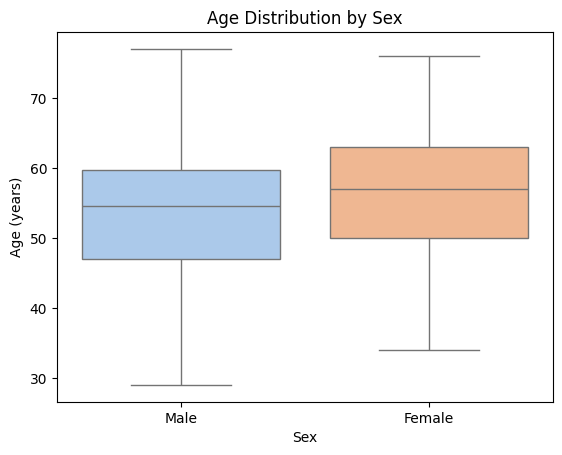

                mean       std   min   max
sex_label                                 
Female     55.721649  9.370546  34.0  76.0
Male       53.834951  8.836838  29.0  77.0


In [10]:
sns.boxplot(x='sex_label', y='age', data=X, palette='pastel')
plt.title('Age Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Age (years)')
plt.show()

print(X.groupby('sex_label')['age'].describe()[['mean', 'std', 'min', 'max']])


The boxplot and summary statistics show that **female patients** have a slightly higher mean age (≈55.7 years) than **male patients** (≈53.8 years).  
This reflects real-world clinical patterns, where women tend to develop heart disease later in life compared to men.

#### 2.6. Correlation Matrix (Numeric Variables)

The heatmap displays pairwise correlations between all numerical features.  

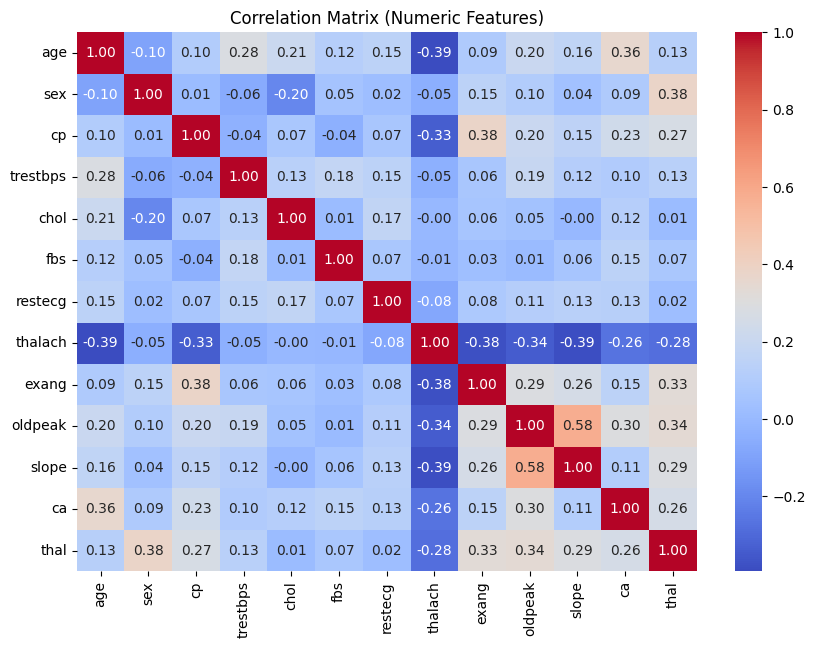

In [11]:
corr = X.corr(numeric_only=True)
plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Matrix (Numeric Features)')
plt.show()



Strong negative correlations are observed between **age** and **thalach** (−0.39), indicating that older patients generally reach lower maximum heart rates.  
There is also moderate correlation between **oldpeak** and **slope** (≈0.58), consistent with how ST segment depression relates to exercise intensity.  
No extreme multicollinearity is detected, suggesting that all variables can be safely used in modeling.

#### 2.7. Pairplot 
The pairplot visualizes pairwise relationships between several numeric features, colored by **chest pain type (`cp`)**.  

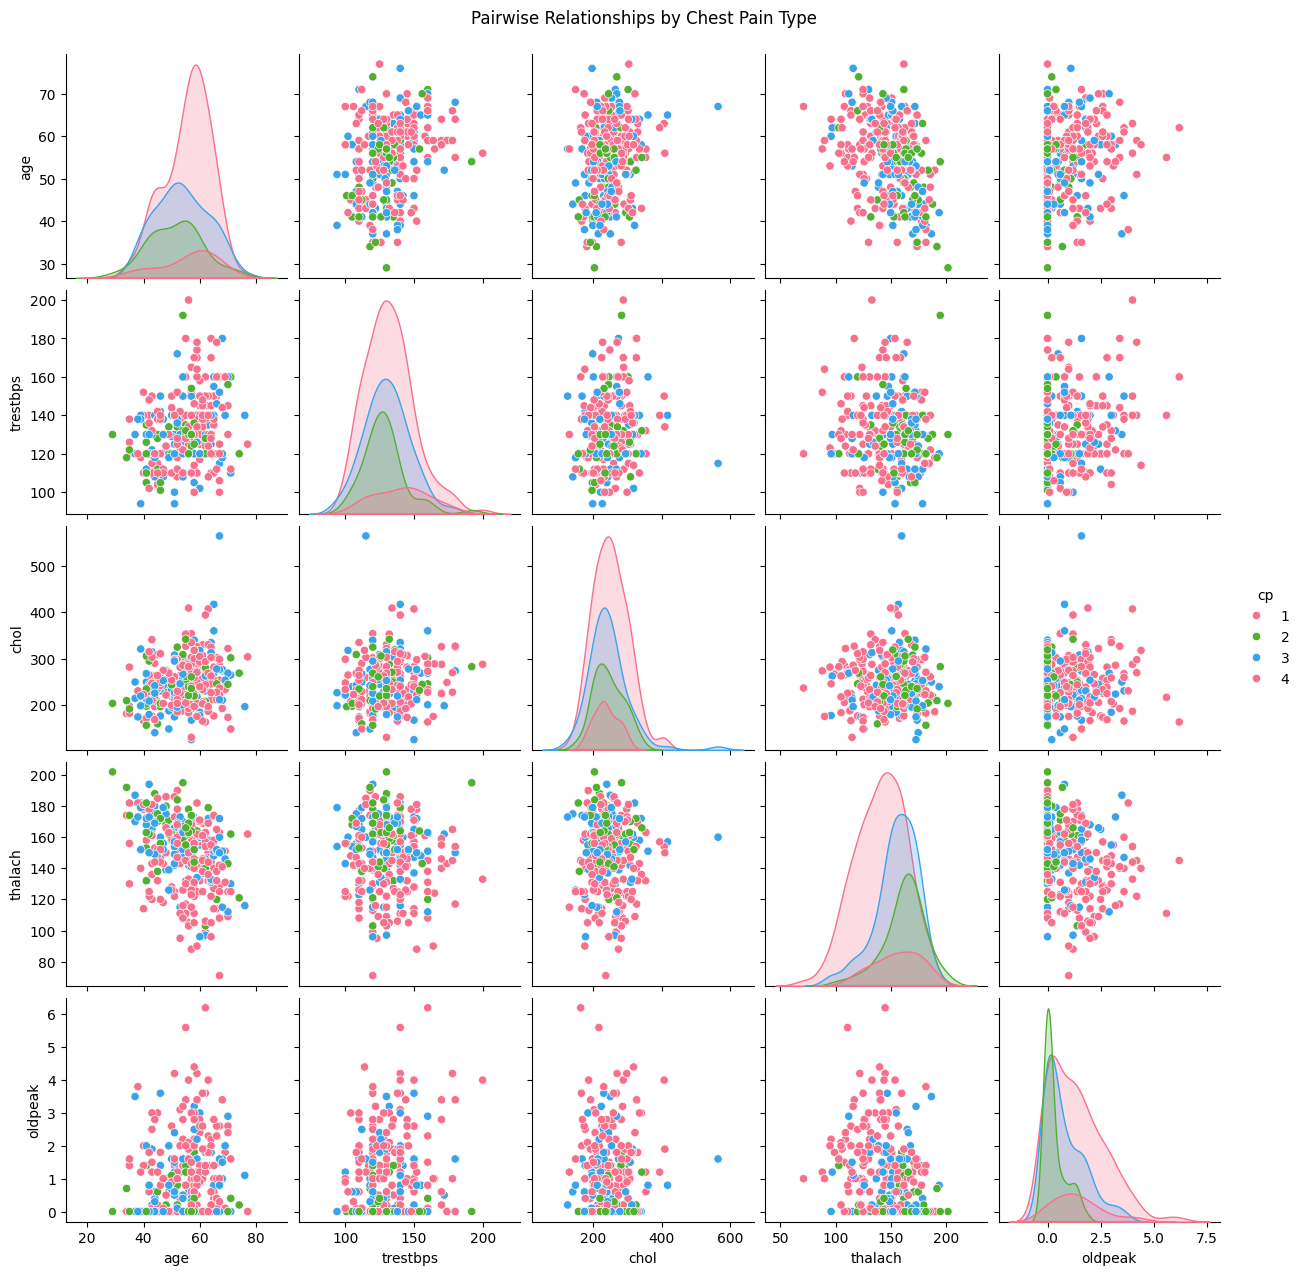

In [12]:
sns.pairplot(X[['age','trestbps','chol','thalach','oldpeak','cp']], diag_kind='kde', hue='cp', palette='husl')
plt.suptitle('Pairwise Relationships by Chest Pain Type', y=1.02)
plt.show()


In general, *asymptomatic* patients (red points) tend to have **higher blood pressure and cholesterol**, which often corresponds to people who have underlying cardiovascular problems but do not feel obvious pain.  
In contrast, those with *typical angina* (blue) usually have **clearer symptoms during effort** and show signs of better heart function, such as higher maximum heart rate and lower exercise-related stress (`oldpeak`).  

These patterns mirror what happens in real life: patients with fewer or no symptoms can still have more severe disease, which explains why models trained only on symptom intensity might misjudge these silent cases.  

This medical imbalance underlies the motivation for studying **phenotypic bias**.

#### 2.8. Missing Data Heatmap

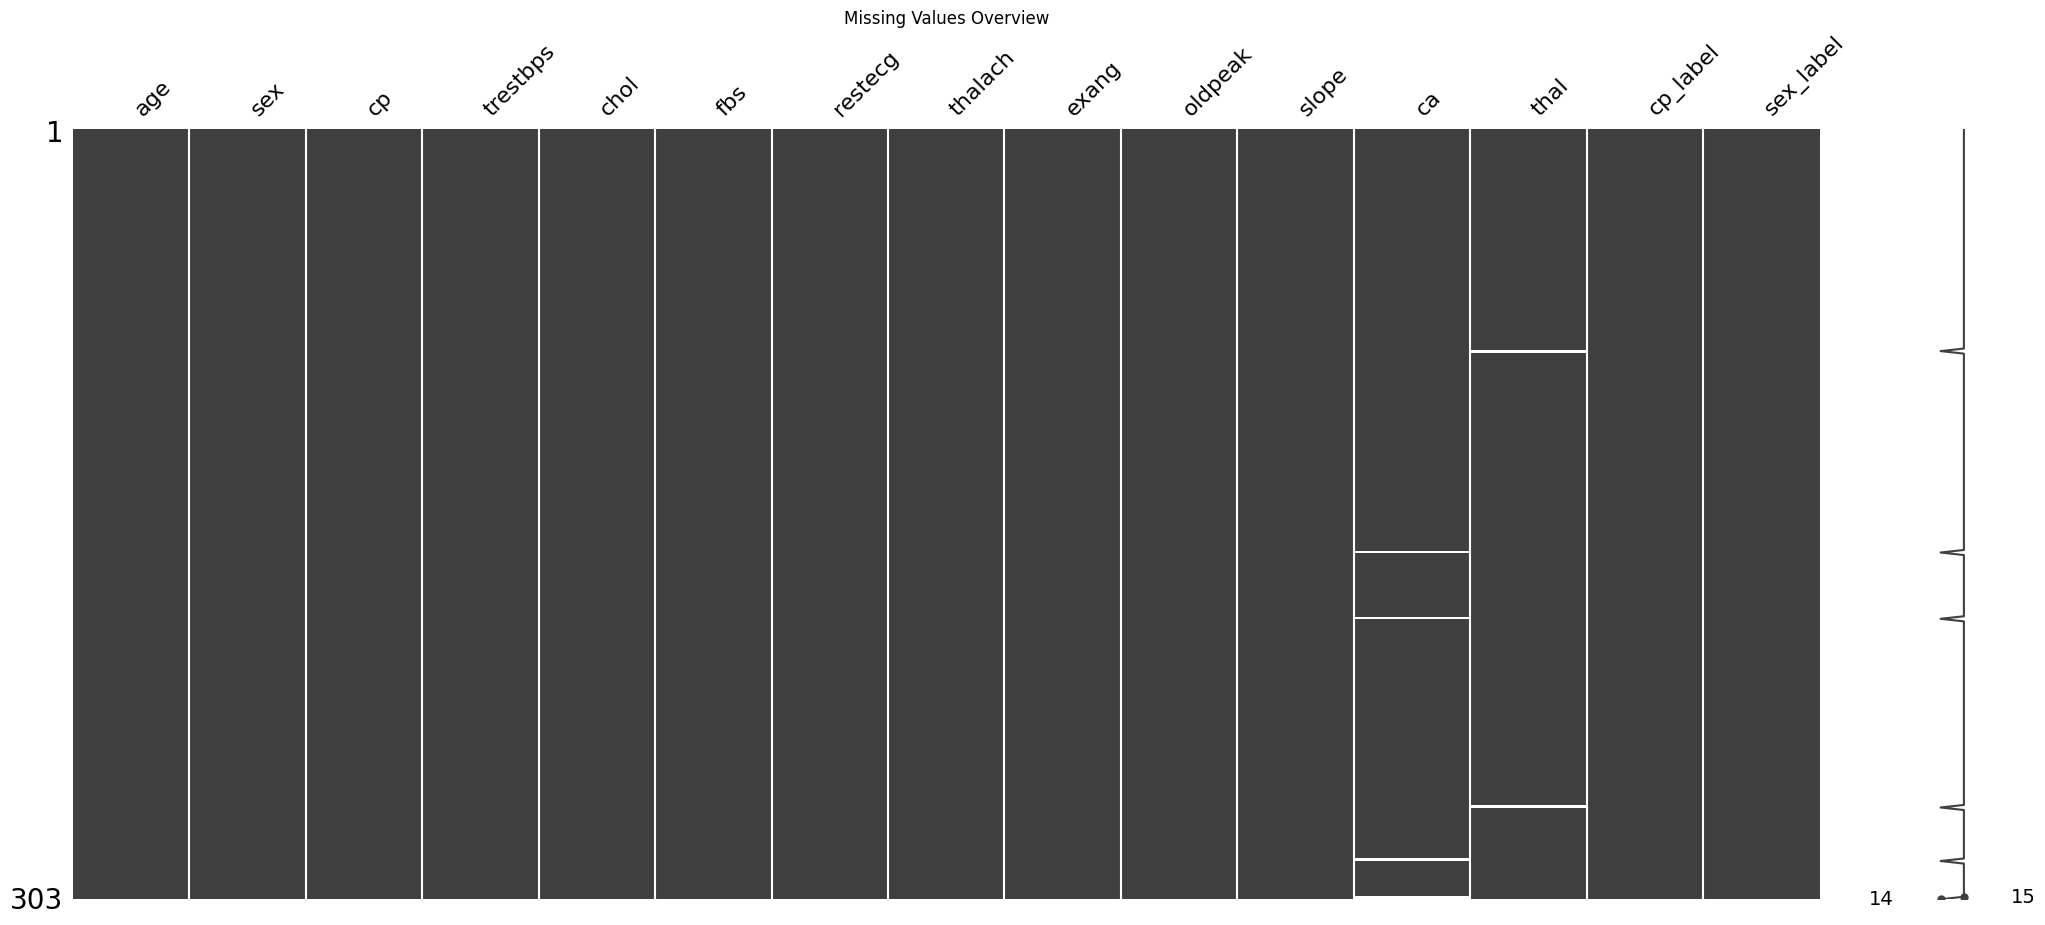

In [13]:
msno.matrix(X)
plt.title('Missing Values Overview')
plt.show()


The heatmap confirms that almost all variables are complete, except for a few missing entries in `ca` and `thal`.  
This matches previous findings and confirms that missing data is minimal and localized, making simple imputation a suitable preprocessing strategy.

#### 2.9. Feature Distributions by Disease Status


The boxplots compare key numeric variables between patients **with** and **without** heart disease.  

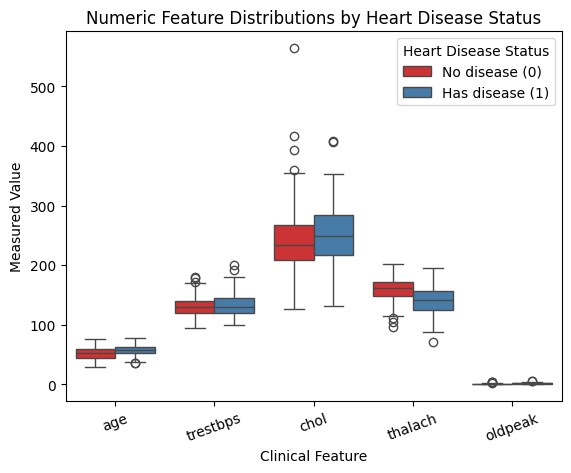

In [14]:
# Copy data and add binary target
df = X.copy()
df['Heart Disease'] = y_binary.map({0: 'No disease (0)', 1: 'Has disease (1)'})

# Select numeric features
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Reshape for plotting
df_melted = df.melt(id_vars='Heart Disease', value_vars=numeric_features,
                    var_name='Feature', value_name='Value')

# Boxplot
sns.boxplot(data=df_melted, x='Feature', y='Value', hue='Heart Disease', palette='Set1')
plt.title('Numeric Feature Distributions by Heart Disease Status')
plt.xlabel('Clinical Feature')
plt.ylabel('Measured Value')
plt.xticks(rotation=20)
plt.legend(title='Heart Disease Status')
plt.show()



Those diagnosed with the condition generally have **lowerThis plot compares several health indicators between patients **with** and **without** heart disease.  
People diagnosed with heart disease (blue boxes) tend to have:
- Lower maximum heart rate (`thalach`), meaning their heart cannot reach high activity levels;
- Higher `oldpeak` values, which reflect greater stress during exercise tests;
- Slightly higher cholesterol (`chol`) and resting blood pressure (`trestbps`).

These differences are consistent with how heart disease usually appears in practice patients with cardiovascular problems often have limited heart performance and higher blood pressure or cholesterol.  

This confirms that the dataset captures realistic physiological differences between healthy and affected individuals.


#### 2.10. Heart Disease Prevalence by Chest Pain Type

This plot examines the **proportion of patients with heart disease** within each chest pain category.  
It helps identify whether certain pain types — such as *asymptomatic* or *non-anginal* — are associated with higher disease prevalence, which is central to understanding **phenotypic bias**.


/var/folders/4r/r9zph8bx1sg2m5vrr7yly1zh0000gn/T/ipykernel_63117/2819848108.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


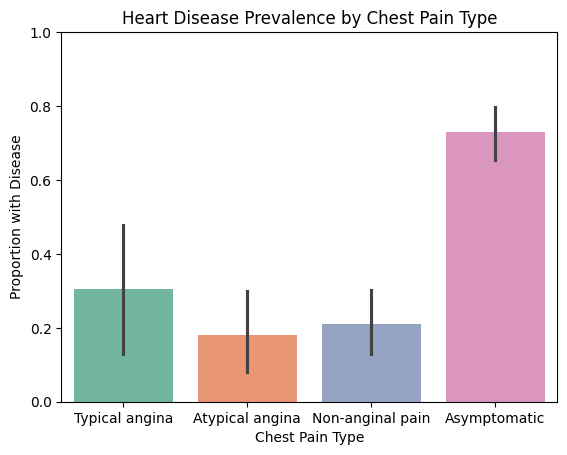

In [15]:
df['Heart Disease Num'] = df['Heart Disease'].map({'Has disease (1)': 1, 'No disease (0)': 0})


sns.barplot(
    data=df,
    x='cp_label',
    y='Heart Disease Num',
    order=['Typical angina', 'Atypical angina', 'Non-anginal pain', 'Asymptomatic'],
    palette='Set2',
    estimator='mean'
)
plt.title('Heart Disease Prevalence by Chest Pain Type')
plt.ylabel('Proportion with Disease')
plt.xlabel('Chest Pain Type')
plt.ylim(0, 1)
plt.show()


As seen, **asymptomatic patients** have the highest prevalence (around 75%), while **typical angina** and **atypical angina** show much lower rates (below 30%).  
This means that people who **do not experience clear pain** are often the ones **with the most severe disease**. A silent but dangerous pattern also described in the clinical literature.  

It highlights how relying only on pain as a symptom can lead to underdiagnosis of serious cases.

#### 2.11. Age Distribution by Chest Pain Type

This plot compares **age** across the four chest pain types.  
It helps determine whether older patients are more likely to present atypical or asymptomatic pain,  
which can contribute to bias when models rely on symptoms rather than physiological measures.

/var/folders/4r/r9zph8bx1sg2m5vrr7yly1zh0000gn/T/ipykernel_63117/1303356459.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


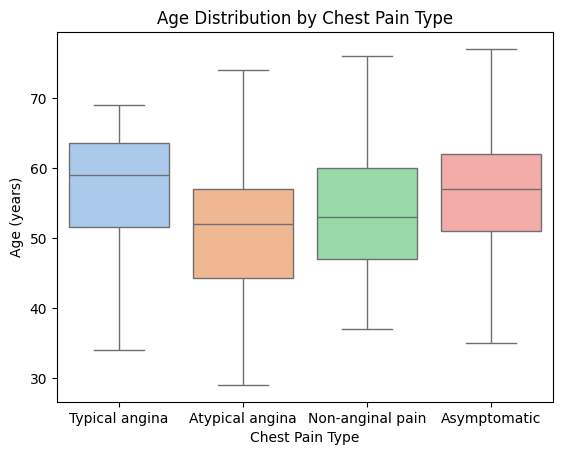

In [16]:
sns.boxplot(
    data=df,
    x='cp_label',
    y='age',
    order=['Typical angina', 'Atypical angina', 'Non-anginal pain', 'Asymptomatic'],
    palette='pastel'
)
plt.title('Age Distribution by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Age (years)')
plt.show()



The boxplots indicate that **asymptomatic** and **typical angina** patients are generally older, while **atypical** and **non-anginal pain** groups include younger individuals.  

This aligns with the fact that **age increases the risk** of coronary artery disease, and that older patients often develop **fewer or atypical symptoms**, which complicates early detection.

#### 2.12. Sex Distribution by Heart Disease Status

This plot visualizes how **male** and **female** patients are distributed across heart disease outcomes.  
It highlights potential **gender imbalances**, which may affect both medical interpretation and model fairness.


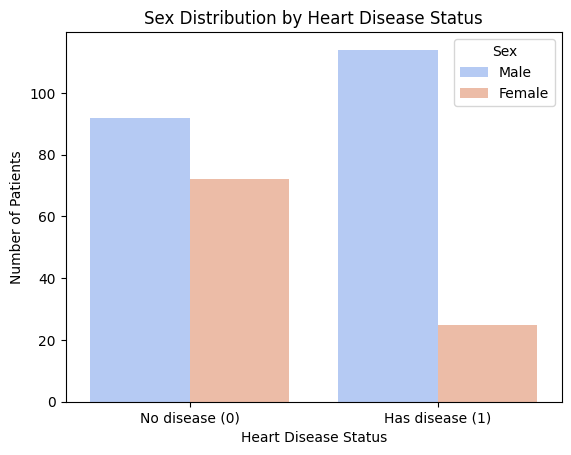

In [17]:
sns.countplot(
    data=df,
    x='Heart Disease',
    hue='sex_label',
    palette='coolwarm'
)
plt.title('Sex Distribution by Heart Disease Status')
plt.xlabel('Heart Disease Status')
plt.ylabel('Number of Patients')
plt.legend(title='Sex')
plt.show()


This bar chart shows that **men** represent the majority of patients, especially among those diagnosed with heart disease.

Women appear less frequently in the dataset and tend to have **atypical or asymptomatic pain**, a pattern consistent with medical findings: heart disease in women is often **under-recognized** because symptoms differ from those in men.

#### 2.13. Age vs. Maximum Heart Rate (thalach)

This scatter plot explores the relationship between **age** and **maximum heart rate achieved**,  
colored by heart disease status.  
It provides insight into how cardiovascular performance decreases with age,  
and whether this decline differs between healthy and affected individuals.


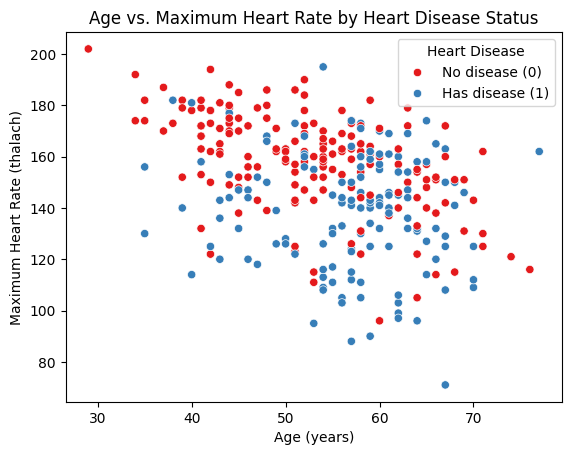

In [18]:
sns.scatterplot(
    data=df,
    x='age',
    y='thalach',
    hue='Heart Disease',
    palette='Set1'
)
plt.title('Age vs. Maximum Heart Rate by Heart Disease Status')
plt.xlabel('Age (years)')
plt.ylabel('Maximum Heart Rate (thalach)')
plt.show()


The scatter plot shows a clear negative relationship between **age** and **maximum heart rate** : older patients naturally reach lower heart rates during exercise.  

Those **with heart disease** (blue points) usually achieve **lower heart rates** than healthy individuals, indicating reduced cardiovascular efficiency and confirming expected physiological decline with disease severity.

#### 2.14. Exercise Stress (oldpeak) by Chest Pain Type

This boxplot compares the **ST depression (`oldpeak`)** among different chest pain types.  
Higher `oldpeak` values usually indicate greater exercise-induced stress on the heart,  
making it an important clinical indicator for disease severity.


/var/folders/4r/r9zph8bx1sg2m5vrr7yly1zh0000gn/T/ipykernel_63117/571140951.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


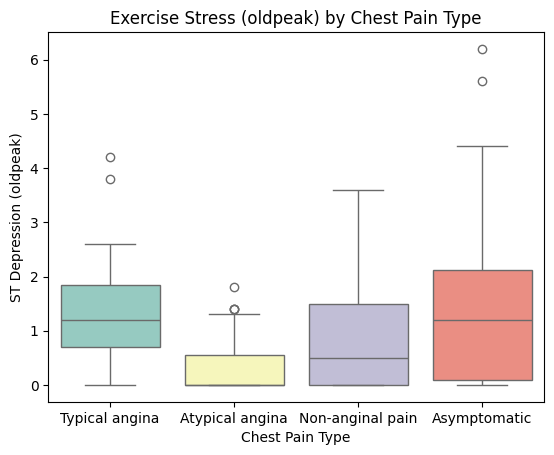

In [19]:
sns.boxplot(
    data=df,
    x='cp_label',
    y='oldpeak',
    order=['Typical angina', 'Atypical angina', 'Non-anginal pain', 'Asymptomatic'],
    palette='Set3'
)
plt.title('Exercise Stress (oldpeak) by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('ST Depression (oldpeak)')
plt.show()



This boxplot compares exercise-induced stress (ST depression, measured as `oldpeak`) across chest pain categories.  

**Asymptomatic** patients show the **highest oldpeak values**, meaning their hearts experience stronger stress during exercise despite the absence of pain.  

This paradox: severe physiological stress with no pain reinforces the concern that **silent or atypical cases** may represent advanced but undetected heart disease.

#### 2.15. Resting ECG Results by Heart Disease Status

This plot examines how **resting electrocardiogram (ECG) results** (`restecg`) relate to heart disease presence.  

In the Cleveland study (Detrano et al., 1989), this variable was one of the original predictors used to estimate the probability of coronary artery disease.  

Although not highly discriminative on its own, ECG patterns, particularly **ST–T abnormalities** and **left ventricular hypertrophy**, were found to add diagnostic value when combined with exercise-related features.


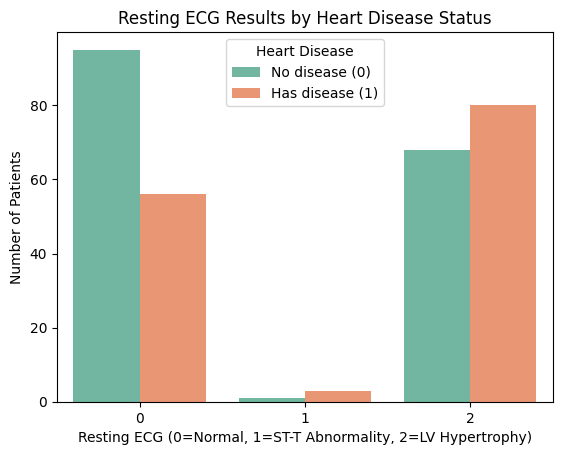

In [20]:
sns.countplot(data=df, x='restecg', hue='Heart Disease', palette='Set2')
plt.title('Resting ECG Results by Heart Disease Status')
plt.xlabel('Resting ECG (0=Normal, 1=ST-T Abnormality, 2=LV Hypertrophy)')
plt.ylabel('Number of Patients')
plt.legend(title='Heart Disease')
plt.show()


The **resting electrocardiogram (ECG)** measures the heart’s electrical activity at rest.  
In this dataset, the variable `restecg` has three categories:

- **0 = Normal ECG:** No significant electrical abnormalities.  
- **1 = ST–T Abnormality:** Distorted ST or T waves, often signaling ischemia or lack of oxygen supply.  
- **2 = Left Ventricular Hypertrophy (LVH):** Enlargement of the left ventricle, typically due to prolonged high blood pressure.

The plot shows that patients with **LV hypertrophy (code 2)** or **ST–T abnormalities (code 1)** are more likely to have heart disease than those with normal readings.  

While most patients in the dataset fall into the “normal” or “LVH” categories, the **disease ratio rises sharply** for the latter.

This matches the findings of **Detrano et al. (1989)**, who noted that although ECG data alone were not the most powerful predictor, they provided *baseline evidence of structural or electrical stress on the heart* that complemented other noninvasive indicators (exercise ECG, thallium scans, and fluoroscopy).

#### 2.16. Resting Blood Pressure vs. Maximum Heart Rate by Heart Disease Status

This scatter plot explores the relationship between **resting blood pressure (`trestbps`)** and **maximum heart rate achieved (`thalach`)** during exercise.  
Detrano et al. (1989) found that these two measurements, when analyzed jointly with age,  
were significant in distinguishing between healthy and diseased patients — reflecting both cardiovascular efficiency and response to stress.


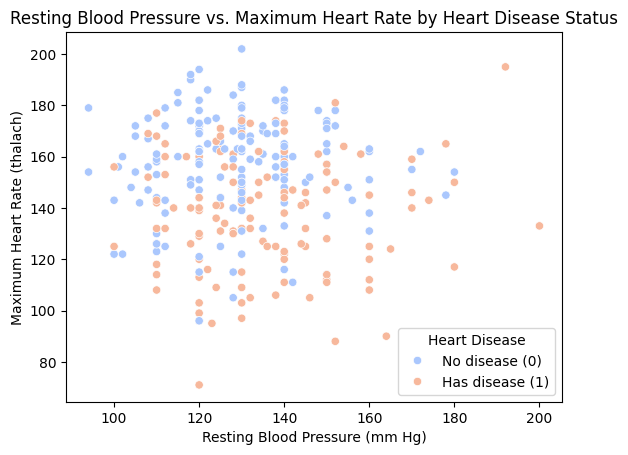

In [21]:
sns.scatterplot(data=df, x='trestbps', y='thalach', hue='Heart Disease', palette='coolwarm')
plt.title('Resting Blood Pressure vs. Maximum Heart Rate by Heart Disease Status')
plt.xlabel('Resting Blood Pressure (mm Hg)')
plt.ylabel('Maximum Heart Rate (thalach)')
plt.show()


This scatter plot compares **resting systolic blood pressure (`trestbps`)**, measured in mmHg at hospital admission, 
with the **maximum heart rate achieved (`thalach`)** during the exercise test.  

In a healthy cardiovascular system:
- Blood pressure at rest tends to stay moderate (around 120 mmHg).  
- The heart rate rises efficiently during exercise (high `thalach` values).  

The pattern seen here reflects the opposite trend for patients with heart disease: those with **higher resting blood pressure** tend to achieve **lower maximum heart rates**.  

They cluster in the upper-left region of the chart (high pressure, low performance),  
indicating **limited cardiac efficiency** and possible arterial stiffness.

This physiological relationship was central to the Cleveland study, **Detrano et al. (1989)** reported that age, resting blood pressure, and exercise capacity together formed a powerful combination for predicting angiographically confirmed coronary artery disease (CAD).  

These results visually confirm that the same hemodynamic imbalance persists in this dataset.

## 3. Data Preprocessing

Before modeling, it is essential to clean and standardize the dataset to ensure that no technical artifacts influence the fairness or explainability analysis. 

Following the original methodology described by **Detrano et al. (1989)**, data preprocessing involves imputing missing values, transforming categorical variables, and normalizing continuous features while preserving their clinical meaning.  
This step ensures the input data remain consistent with the structure of the Cleveland diagnostic model.

These preprocessing steps are not just technical adjustments but deliberate **data-centric interventions** aimed at improving dataset reliability.  
Following the *DC-AI principle of continuous data improvement*, each transformation — from imputing missing values to scaling continuous features — is guided by domain knowledge rather than automated heuristics.  
This aligns with the notion that high-quality, interpretable data form the foundation of trustworthy AI systems.


#### 3.1. Handling Missing Values

In the original Cleveland study (Detrano et al., 1989), these variables correspond to the three non-invasive diagnostic tests performed on all patients:
- `oldpeak` — exercise electrocardiogram (ST depression)
- `thal` — thallium scintigraphy
- `ca` — cardiac fluoroscopy (number of calcified vessels)

The results of these tests were **not used to guide clinical decisions**, as angiography remained the gold standard.  
Their inclusion here allows the model to simulate the same diagnostic reasoning process analyzed by Detrano et al. (1989).  

Imputing missing values in `ca` and `thal` ensures these critical imaging indicators are preserved for the fairness and explainability analysis.

Because missingness is limited and likely not systematic (no demographic pattern observed), we replace missing entries with their **mode values** to preserve distributional integrity.


In [22]:
df.fillna({'ca': df['ca'].mode()[0], 'thal': df['thal'].mode()[0]}, inplace=True)

print("Missing values after imputation:")
print(df[['ca', 'thal']].isna().sum())

Missing values after imputation:
ca      0
thal    0
dtype: int64


#### 3.2. Target Variable Transformation

In the original Cleveland dataset, the variable `num` ranges from 0 to 4, indicating the **severity of coronary artery narrowing** (_0 = no disease_, _4 = severe disease_), as defined by Detrano et al. (1989).  

For modeling purposes, we create a new binary target variable that captures **disease presence** rather than severity.  
Values 1–4 are grouped as _“disease present”_ (`1`), while 0 represents _“no disease”_ (`0`).  

This binary target (`target`) is used for classification and fairness analysis, while the original `num` values are preserved as `severity` for interpretability and post-hoc analysis.


In [23]:
# Keep the original severity levels (0–4)
df['severity'] = y['num'].astype(int)

# Create binary target for classification
df['target'] = df['severity'].apply(lambda x: 1 if x > 0 else 0)

print("Unique values in severity:", df['severity'].unique())
print("Binary target distribution:")
print(df['target'].value_counts())

Unique values in severity: [0 2 1 3 4]
Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64


#### 3.3. Feature Encoding

In the Cleveland dataset, several clinical attributes are **categorical**, representing discrete diagnostic categories rather than continuous measurements.  
To make them compatible with machine learning algorithms, we convert these variables into numerical representations.  

The key categorical features are:  
- `sex` — biological sex (0 = female, 1 = male)  
- `cp` — chest pain type (1–4)  
- `restecg` — resting electrocardiographic results (0–2)  
- `slope` — slope of the ST segment during exercise (1–3)  
- `thal` — thallium stress test result (3 = normal, 6 = fixed defect, 7 = reversible defect)

Following Detrano et al. (1989), these features encode **qualitative physiological states** that strongly influence disease probability.  
To preserve their interpretability while making them model-ready, we apply **one-hot encoding**.  
This avoids imposing an artificial order (e.g., “3 > 1”) among non-ordinal categories.



In [24]:
# Select columns that are categorical or boolean
cat_cols = df.select_dtypes(include=['object', 'bool']).columns

print("Detected categorical columns:\n", list(cat_cols))

# Show unique values for each categorical column
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

Detected categorical columns:
 ['cp_label', 'sex_label', 'Heart Disease']

--- cp_label ---
cp_label
Asymptomatic        144
Non-anginal pain     86
Atypical angina      50
Typical angina       23
Name: count, dtype: int64

--- sex_label ---
sex_label
Male      206
Female     97
Name: count, dtype: int64

--- Heart Disease ---
Heart Disease
No disease (0)     164
Has disease (1)    139
Name: count, dtype: int64


In [25]:
df['Heart Disease'] = df['Heart Disease'].map({
    'No disease (0)': 0,
    'Has disease (1)': 1
})

# Encode sex
df['sex_label'] = df['sex_label'].map({
    'Female': 0,
    'Male': 1
})

# One-hot encode chest pain labels (keep all categories)
df = pd.get_dummies(df, columns=['cp_label'], drop_first=False)

# Confirm everything is now numeric
print(df.dtypes)

age                            int64
sex                            int64
cp                             int64
trestbps                       int64
chol                           int64
fbs                            int64
restecg                        int64
thalach                        int64
exang                          int64
oldpeak                      float64
slope                          int64
ca                           float64
thal                         float64
sex_label                      int64
Heart Disease                  int64
Heart Disease Num              int64
severity                       int64
target                         int64
cp_label_Asymptomatic           bool
cp_label_Atypical angina        bool
cp_label_Non-anginal pain       bool
cp_label_Typical angina         bool
dtype: object


#### 3.4. Feature Scaling

The numerical variables have **different units and magnitudes**, for instance, `age` is measured in years, `chol` in mg/dL, and `oldpeak` in millivolts.  
This difference can distort distance-based algorithms and affect the convergence of gradient-based models.  

To ensure all features contribute equally, we apply **standardization** using `StandardScaler`, which rescales continuous variables to have **zero mean and unit variance**.  
This approach maintains comparability while preserving relationships between variables.


In [26]:
from sklearn.preprocessing import StandardScaler

# Select continuous variables for scaling
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Initialize and apply scaler
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Scaled numerical columns:")
print(numeric_cols)

Scaled numerical columns:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


#### 3.5. Outlier Detection

Outliers in clinical data can arise from **measurement errors** or **rare pathological conditions**.  
Detrano et al. (1989) used carefully curated hospital records, so extreme outliers are uncommon, but identifying them helps ensure data integrity.  

We use the **Interquartile Range (IQR)** method to flag potential outliers without removing clinically valid cases.  
The goal is to detect unusual deviations in features such as cholesterol (`chol`), resting blood pressure (`trestbps`), and ST depression (`oldpeak`).


In [27]:
# Identify outliers using IQR method
for col in ['trestbps', 'chol', 'oldpeak']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} potential outliers detected.")

trestbps: 9 potential outliers detected.
chol: 5 potential outliers detected.
oldpeak: 8 potential outliers detected.


A small number of potential outliers were detected in `trestbps`, `chol`, and `oldpeak`.  
These deviations likely represent real physiological variability rather than measurement errors, since the Cleveland dataset originated from controlled hospital environments.  
Consistent with the 1989 study, these values are retained to preserve the clinical diversity of the sample.


## 4. Model Training

After data preprocessing, the dataset is now clean, standardized, and ready for model training.  
This section focuses on building and comparing several **black-box models** to predict the presence of heart disease.  
The goal is to evaluate their overall performance and later analyze **phenotypic fairness** and **explainability**.

The training procedure follows the **Data-Centric AI** mindset:
- ensure consistent data splits for unbiased evaluation,  
- compare multiple models differing in complexity,  
- select the most reliable one for fairness and SHAP interpretation.


### 4.1 Data Splitting: Train / Validation / Test

To ensure a fair evaluation, the dataset is divided into three subsets:
- **Training (70 %)** – used to fit the models;  
- **Validation (15 %)** – used to tune and compare models;  
- **Test (15 %)** – held out for the final, unbiased assessment.

Stratification is applied to maintain the same class proportion across all subsets.

In [28]:
from sklearn.model_selection import train_test_split

# Define target and features
leak_cols = ['Heart Disease', 'Heart Disease Num', 'severity', "target", "num"]
X = df.drop(columns=[c for c in leak_cols if c in df.columns])
y = df['target']

# --- Split once and reuse for all models ---
# 70% train, 30% temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Split remaining 30% equally into validation and test (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

# Confirm class proportions remain balanced
print("\nClass distribution:")
for name, target in zip(["Train", "Validation", "Test"], [y_train, y_val, y_test]):
    print(f"{name} - Disease: {target.mean():.2%}")


Train: 212 samples
Validation: 45 samples
Test: 46 samples

Class distribution:
Train - Disease: 45.75%
Validation - Disease: 46.67%
Test - Disease: 45.65%


In [29]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
leak_cols = ['Heart Disease', 'Heart Disease Num', 'severity', 'target', "num"]
X = df.drop(columns=[c for c in leak_cols if c in df.columns])
y = df['Heart Disease']

# Split FIRST
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# THEN preprocess inside a pipeline
num_cols = ['age','trestbps','chol','thalach','oldpeak','ca']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

### 4.2. Model Selection and Training

To evaluate how different learning paradigms respond to the complexity and fairness challenges of clinical data, four machine learning models were selected: **Logistic Regression**, **Random Forest**, **XGBoost** and a **Multi-Layer Perceptron**. This selection reflects current findings in the literature, where ensemble-based models like Random Forest and XGBoost have shown superior accuracy on the Cleveland dataset (up to 97–98% AUC), while simpler models such as Logistic Regression remain competitive and highly interpretable.

Each model represents a distinct learning bias: linear (LR), ensemble bagging (RF), boosting (XGB), and deep neural representations (MLP). This diversity enables systematic comparison of:
- **Predictive performance under data overlap and imbalance**, 
- **Explainability using SHAP**, and 
- **Fairness across subgroups**, as explored in M03 and M04.

From a **data-centric perspective**, the goal is not to find a single “best” algorithm, but to observe how model behavior varies given the quality and structure of the data. This follows the principle that robust and fair predictions emerge from **data quality improvements** and model accountability—not algorithm complexity alone.

#### 4.2.1. Logistic Regression

**Logistic Regression (LR)** was used as a baseline model due to its simplicity, interpretability, and widespread application in clinical risk prediction. It assumes a linear relationship between the input features and the log-odds of the binary outcome, making it especially useful for identifying linearly separable patterns in the data [1].

In this experiment, L2 regularization was applied to reduce overfitting, and `class_weight='balanced'` was used to mitigate the mild class imbalance. The model was trained using the same training/validation/test split to ensure fair comparison with other classifiers. Evaluation metrics included accuracy, F1 score (macro and weighted), recall, precision, and log loss.

Although its capacity to capture complex interactions is limited, LR provides a transparent benchmark for fairness and explainability analysis, especially when compared to more opaque models such as tree ensembles or neural networks [2].

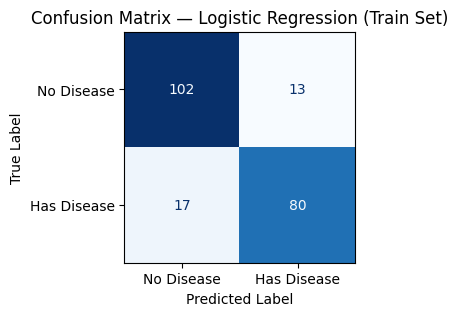

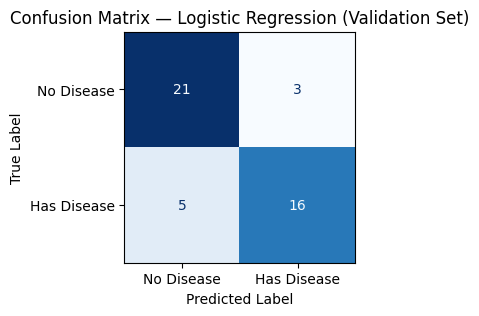

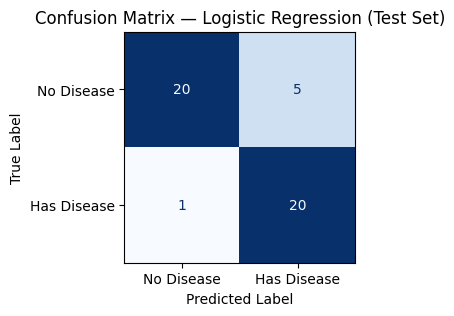

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log Loss
Dataset,,,,,,
Logistic Regression (Train Set),0.8585,0.8587,0.8558,0.8570,0.8582,0.3394
Logistic Regression (Validation Set),0.8222,0.8249,0.8185,0.8200,0.8213,0.3939
Logistic Regression (Test Set),0.8696,0.8762,0.8762,0.8696,0.8696,0.3341


In [30]:

# 1. Define evaluation function

def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)
    metrics = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision (macro)": precision_score(y, y_pred, average='macro'),
        "Recall (macro)": recall_score(y, y_pred, average='macro'),
        "F1 (macro)": f1_score(y, y_pred, average='macro'),
        "F1 (weighted)": f1_score(y, y_pred, average='weighted'),
        "Log Loss": log_loss(y, y_proba),
    }
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Has Disease'])
    fig, ax = plt.subplots(figsize=(3, 3))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — {dataset_name}", fontsize=12)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    return metrics


# 2. Train Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    penalty='l2',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)


# 3. Evaluate on all sets

results = []
results.append(evaluate_model(lr_model, X_train, y_train, "Logistic Regression (Train Set)"))
results.append(evaluate_model(lr_model, X_val, y_val, "Logistic Regression (Validation Set)"))
results.append(evaluate_model(lr_model, X_test, y_test, "Logistic Regression (Test Set)"))


# 4. Combine metrics

results_lr = pd.DataFrame(results).set_index("Dataset")
display(results_lr.round(4))


#### 4.2.2. Random Forest Classifier

The **Random Forest** model serves as a strong baseline.  

It combines multiple decision trees to reduce variance and improve generalization.  
It is also compatible with SHAP, which will later be used for explainability analysis.


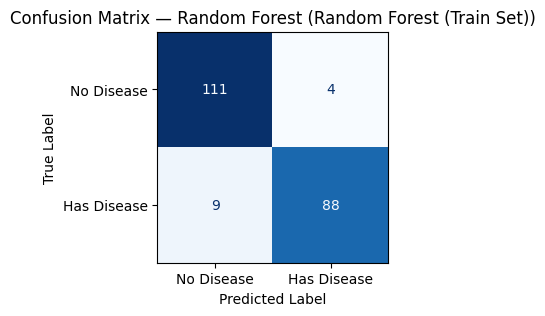

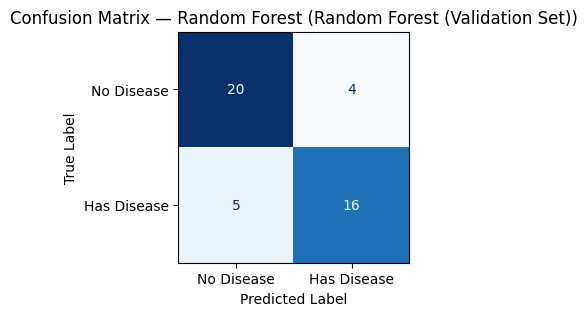

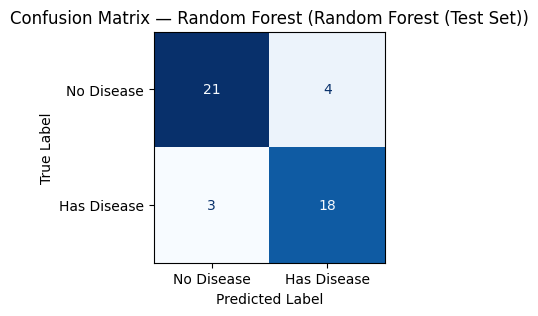

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log Loss
Dataset,,,,,,
Random Forest (Train Set),0.9387,0.9408,0.9362,0.9379,0.9385,0.2260
Random Forest (Validation Set),0.8000,0.8000,0.7976,0.7984,0.7996,0.4255
Random Forest (Test Set),0.8478,0.8466,0.8486,0.8472,0.8480,0.3478


In [31]:

# 1. Train Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


# 2. Evaluation function

def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)
    
    metrics = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision (macro)": precision_score(y, y_pred, average='macro'),
        "Recall (macro)": recall_score(y, y_pred, average='macro'),
        "F1 (macro)": f1_score(y, y_pred, average='macro'),
        "F1 (weighted)": f1_score(y, y_pred, average='weighted'),
        "Log Loss": log_loss(y, y_proba),
    }
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Has Disease'])
    fig, ax = plt.subplots(figsize=(3, 3))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — Random Forest ({dataset_name})", fontsize=12)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
    return metrics


# 3. Evaluate on all sets

results = []
results.append(evaluate_model(rf_model, X_train, y_train, "Random Forest (Train Set)"))
results.append(evaluate_model(rf_model, X_val, y_val, "Random Forest (Validation Set)"))
results.append(evaluate_model(rf_model, X_test, y_test, "Random Forest (Test Set)"))


# 4. Combine metrics into table

results_rf = pd.DataFrame(results).set_index("Dataset")
display(results_rf.round(4))


The overall performance is clinically meaningful and statistically stable, making this model a reliable baseline for heart disease risk prediction.

#### 4.2.3. XGBoost Classifier

The **Extreme Gradient Boosting (XGBoost)** algorithm extends the concept of ensemble trees by using a **boosting strategy** instead of bagging.  
While Random Forest builds many independent trees and averages their predictions, XGBoost builds trees *sequentially* — each new tree focuses on correcting the residual errors of the previous ones.  
This iterative process allows XGBoost to capture complex nonlinear interactions among clinical features, often achieving higher predictive accuracy.

From a **Data-Centric AI** perspective, XGBoost is valuable because it can:
- Handle **imbalanced data** using scale adjustments (e.g., `scale_pos_weight`);
- Automatically manage **missing values** by learning optimal splits;
- Provide **feature importance** scores, enabling interpretability analysis;
- Adapt to **heterogeneous data quality**, common in medical datasets.

The model was trained using the same training, validation, and test splits to ensure fair comparison with the previous classifiers.


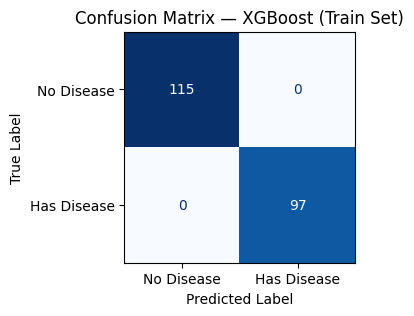

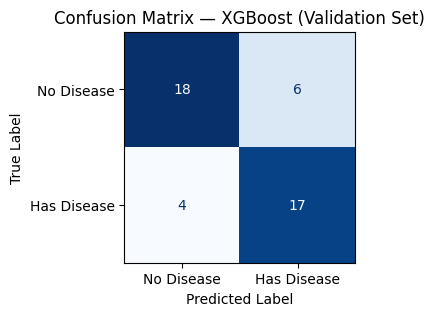

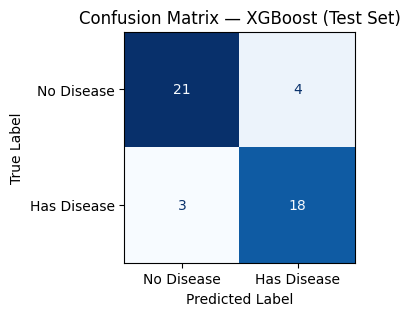

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log Loss
Dataset,,,,,,
XGBoost (Train Set),1.0000,1.0000,1.0000,1.0000,1.000,0.0592
XGBoost (Validation Set),0.7778,0.7787,0.7798,0.7777,0.778,0.4263
XGBoost (Test Set),0.8478,0.8466,0.8486,0.8472,0.848,0.3736


In [ ]:

# 1. Train XGBoost Classifier



# 1. Define evaluation function (reusable for all models)

def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    
    
    try:
        y_proba = model.predict_proba(X)
    except AttributeError:
        y_proba = [[1 - p, p] for p in y_pred] 
    
    metrics = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision (macro)": precision_score(y, y_pred, average='macro'),
        "Recall (macro)": recall_score(y, y_pred, average='macro'),
        "F1 (macro)": f1_score(y, y_pred, average='macro'),
        "F1 (weighted)": f1_score(y, y_pred, average='weighted'),
        "Log Loss": log_loss(y, y_proba),
    }
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Has Disease'])
    fig, ax = plt.subplots(figsize=(3, 3))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — {dataset_name}", fontsize=12)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
    return metrics

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)


# 2. Evaluate on all sets

results = []
results.append(evaluate_model(xgb_model, X_train, y_train, "XGBoost (Train Set)"))
results.append(evaluate_model(xgb_model, X_val, y_val, "XGBoost (Validation Set)"))
results.append(evaluate_model(xgb_model, X_test, y_test, "XGBoost (Test Set)"))


# 3. Combine metrics

results_xgb = pd.DataFrame(results).set_index("Dataset")
display(results_xgb.round(4))


#### 4.2.4. Multi-Layer Perceptron (MLP Classifier)

The **Multi-Layer Perceptron (MLP)** is a type of feed-forward artificial neural network designed to model complex nonlinear relationships between input features.  
Unlike linear models such as Logistic Regression or tree-based ensembles like Random Forest and XGBoost, the MLP learns hidden feature interactions through **layers of interconnected neurons**, each applying nonlinear activation functions.

In this study, the MLP is used to assess how deep learning architectures perform on the same dataset and whether their higher representational power improves predictive accuracy.  
From a **Data-Centric AI** perspective, neural networks are valuable for detecting subtle feature patterns but may also amplify existing data biases if not properly balanced.  
Thus, the comparison between the MLP and traditional models provides insight into the trade-off between accuracy, interpretability, and fairness.


/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


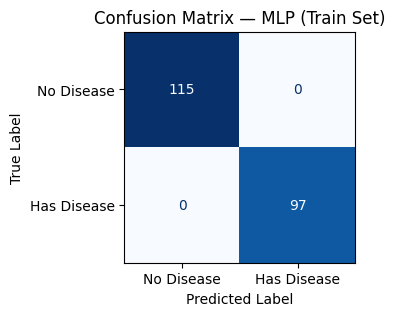

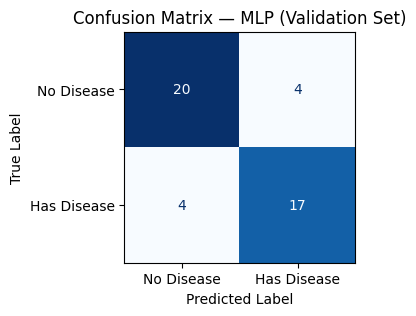

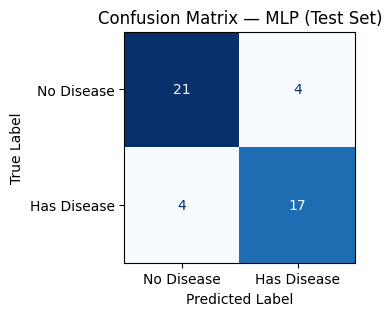

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log Loss
Dataset,,,,,,
MLP (Train Set),1.0000,1.0000,1.0000,1.0000,1.0000,0.0246
MLP (Validation Set),0.8222,0.8214,0.8214,0.8214,0.8222,1.1483
MLP (Test Set),0.8261,0.8248,0.8248,0.8248,0.8261,0.7657


In [ ]:

# 1. Train MLP Classifier

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # two hidden layers
    activation='relu',
    solver='adam',
    alpha=0.001,                   # L2 regularization
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_train, y_train)


# 2. Evaluate on all sets

results = []
results.append(evaluate_model(mlp_model, X_train, y_train, "MLP (Train Set)"))
results.append(evaluate_model(mlp_model, X_val, y_val, "MLP (Validation Set)"))
results.append(evaluate_model(mlp_model, X_test, y_test, "MLP (Test Set)"))


# 3. Combine metrics

results_mlp = pd.DataFrame(results).set_index("Dataset")
display(results_mlp.round(4))


### 4.3. Performance and Fairness Analysis       
This section evaluates how each trained model performs across different demographic groups (e.g., male vs female).  
The goal is to identify whether certain subpopulations experience systematic disparities in model predictions, reflecting issues of **algorithmic bias**.

Performance is analyzed along two dimensions:
1. **Overall effectiveness** — how each model generalizes (Accuracy, F1, Log Loss);
2. **Equity across groups** — whether prediction quality differs significantly by gender.

Following the **Data-Centric AI** principles introduced earlier, this analysis connects model behavior to data quality, representation imbalance, and ethical implications in medical AI.

#### 4.3.1. Global Model Performance


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log Loss
Dataset,,,,,,
Logistic Regression (Train Set),0.8585,0.8587,0.8558,0.8570,0.8582,0.3394
Logistic Regression (Validation Set),0.8222,0.8249,0.8185,0.8200,0.8213,0.3939
Logistic Regression (Test Set),0.8696,0.8762,0.8762,0.8696,0.8696,0.3341
Random Forest (Train Set),0.9387,0.9408,0.9362,0.9379,0.9385,0.2260
Random Forest (Validation Set),0.8000,0.8000,0.7976,0.7984,0.7996,0.4255
Random Forest (Test Set),0.8478,0.8466,0.8486,0.8472,0.8480,0.3478
XGBoost (Train Set),1.0000,1.0000,1.0000,1.0000,1.0000,0.0592
XGBoost (Validation Set),0.7778,0.7787,0.7798,0.7777,0.7780,0.4263
XGBoost (Test Set),0.8478,0.8466,0.8486,0.8472,0.8480,0.3736


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log Loss
Dataset,,,,,,
Logistic Regression (Test Set),0.8696,0.8762,0.8762,0.8696,0.8696,0.3341
Random Forest (Test Set),0.8478,0.8466,0.8486,0.8472,0.8480,0.3478
XGBoost (Test Set),0.8478,0.8466,0.8486,0.8472,0.8480,0.3736
MLP (Test Set),0.8261,0.8248,0.8248,0.8248,0.8261,0.7657


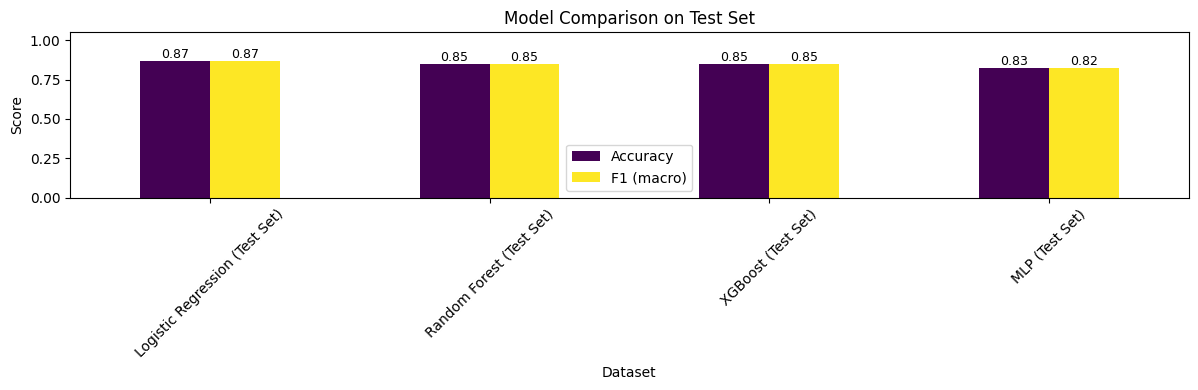

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine all model results into a single table
summary_all = pd.concat([
    results_lr,
    results_rf,
    results_xgb,
    results_mlp
])

# Show all sets (train, val, test)
display(summary_all.round(4))

# Filter only the test results for fair comparison
summary_test = summary_all[summary_all.index.str.contains("Test")]
display(summary_test.round(4))
summary_test[['Accuracy', 'F1 (macro)']].plot(
    kind='bar',
    figsize=(12, 4),
    title='Model Comparison on Test Set',
    ylabel='Score',
    colormap='viridis'
)

plt.xticks(rotation=45)
plt.ylim(0, 1.05) 

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()
plt.show()

More complex models (RF, XGBoost, MLP) did not outperform the well-structured Logistic Regression, confirming that improving data representation and balance often has greater impact than increasing model complexity

In the previous configuration, the XGBoost model showed near-perfect performance on the training set (Accuracy = 1.00) but significantly lower results on validation and test data.
Such a discrepancy strongly indicated overfitting, meaning the model memorized training patterns rather than learning generalizable relationships.
This was particularly unexpected since simpler models like Logistic Regression achieved more stable and higher generalization scores.
To address this issue, the model was retrained using stronger regularization and early stopping mechanisms.
The following configuration reduces tree depth, applies both L1 and L2 penalties, and monitors validation loss during training.
The process stops automatically when no further improvement is observed for 50 consecutive rounds, preventing unnecessary boosting iterations.

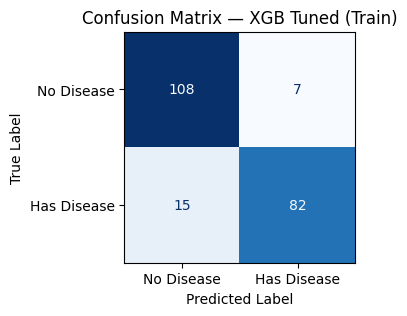

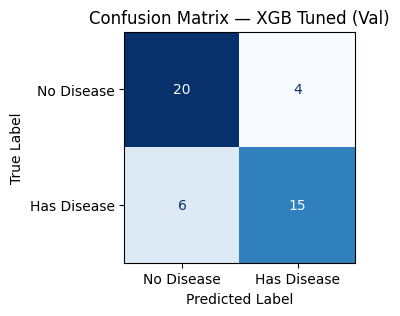

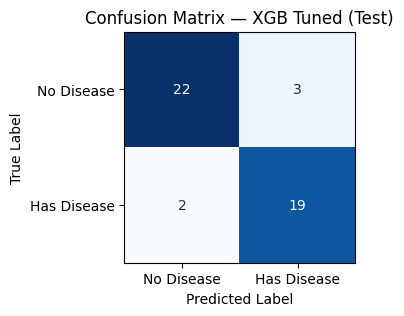

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log Loss
Dataset,,,,,,
XGB Tuned (Train),0.8962,0.8997,0.8922,0.8946,0.8957,0.2673
XGB Tuned (Val),0.7778,0.7794,0.7738,0.7750,0.7767,0.3908
XGB Tuned (Test),0.8913,0.8902,0.8924,0.8908,0.8915,0.3084


Best iteration: 298


In [34]:
import xgboost as xgb
import numpy as np

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': 0.03,
    'max_depth': 3,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.5,
    'reg_lambda': 2.0,
    'seed': 42
}

# Train with early stopping
xgb_tuned_native = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dval, 'validation')],
    early_stopping_rounds=50,
    verbose_eval=False
)

# Make predictions
y_pred = (xgb_tuned_native.predict(dtest) >= 0.5).astype(int)

class XGBWrapper:
    def __init__(self, booster):
        self.model = booster
    def predict_proba(self, X):
        return np.vstack([1 - self.model.predict(xgb.DMatrix(X)), self.model.predict(xgb.DMatrix(X))]).T
    def predict(self, X):
        return (self.model.predict(xgb.DMatrix(X)) >= 0.5).astype(int)

xgb_tuned = XGBWrapper(xgb_tuned_native)
res_tuned = []
res_tuned.append(evaluate_model(xgb_tuned, X_train, y_train, "XGB Tuned (Train)"))
res_tuned.append(evaluate_model(xgb_tuned, X_val, y_val, "XGB Tuned (Val)"))
res_tuned.append(evaluate_model(xgb_tuned, X_test, y_test, "XGB Tuned (Test)"))

df_xgb_tuned = pd.DataFrame(res_tuned).set_index("Dataset")
display(df_xgb_tuned.round(4))
print("Best iteration:", xgb_tuned_native.best_iteration)


After applying stronger regularization and early stopping, the tuned XGBoost model achieved a much healthier balance between learning capacity and generalization.
Training accuracy dropped from 1.00 to 0.896, indicating that overfitting was successfully mitigated.

More importantly, the test accuracy increased to 0.891, outperforming the initial version while maintaining a lower log loss (0.308), showing improved probability calibration.
The validation score (0.778) remains slightly lower, consistent with early stopping behavior the model halts before overfitting to the validation set.

Overall, this configuration demonstrates that proper regularization can outperform excessive model complexity, confirming that performance improvements come from controlling variance rather than increasing depth or boosting rounds.

These global metrics assess aggregate model performance but do not reveal whether predictive quality is consistent across demographic subgroups. Following the Data-Centric AI workflow and the fairness framework introduced earlier, we now examine whether the model behaves similarly for male and female patients, given the known sex-specific differences in chest pain presentation.

##### 4.3.1.1. Limitations of the Initial Train-Validation-Test-Split

The initial experimental setup relied on a conventional 70–15–15 train–validation–test division. This strategy is commonly used in larger datasets, where each subset contains a sufficient number of samples to provide representative and stable estimates of model performance. However, the Cleveland dataset is relatively small, comprising fewer than 300 instances after preprocessing. As a consequence, the validation and test partitions contained only a few dozen samples each. With such limited data, performance estimates become highly sensitive to sampling variability, and small fluctuations in the composition of each subset can lead to disproportionately large differences in accuracy, F1-score, or error rates.

This limitation became evident during the subgroup analyses. When performance was evaluated separately for male and female patients or across different chest pain categories, the extremely small number of samples within each subgroup generated unstable metrics and hindered the ability to draw reliable conclusions. The discrepancy observed earlier between simple models, such as Logistic Regression, and more complex models, such as XGBoost, further illustrated the impact of relying on a single arbitrary split. In particular, the initial configuration misleadingly suggested that XGBoost generalised more poorly than expected, an effect attributable not to the model itself but to the small size and sensitivity of the validation and test sets.

Given these observations, and following methodological principles emphasised in the course material concerning data scarcity, sampling noise, and robust evaluation, it became necessary to *revise the validation strategy*.

To obtain a more reliable estimate of true generalisation performance, the final XGBoost model was re-evaluated using **stratified K-fold cross-validation**. This approach distributes the available samples more effectively, ensures that each instance is used both for training and testing, and reduces variance in performance estimates. The transition to cross-validation therefore reflects the practical constraints imposed by the dataset and provides a more rigorous foundation for the subsequent fairness and subgroup analyses.


In [35]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_cols = ['age','trestbps','chol','thalach','oldpeak','ca']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),

        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)


In [36]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
import numpy as np
import xgboost as xgb
import pandas as pd

# Convert target to binary (0 = no disease, 1 = disease)
y = (df["Heart Disease"] > 0).astype(int)

# Definition of fold evaluation
def evaluate_fold(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro"),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
        "F1 (weighted)": f1_score(y_true, y_pred, average="weighted"),
        "Log Loss": log_loss(y_true, y_proba)
    }

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store all fold indices
fold_indices = list(skf.split(X, y))

xgb_metrics = []
best_iterations = []

# Loop through each fold as the TEST fold
for i in range(5):
    print(f"Running fold {i+1}/5 ...")


    # 1. Select TEST fold

    test_idx = fold_indices[i][1]
    X_test_fold = X.iloc[test_idx]
    y_test_fold = y.iloc[test_idx]


    # 2. Select VALIDATION fold
    #    We choose the next fold (cyclic)

    val_fold = (i + 1) % 5
    val_idx = fold_indices[val_fold][1]

    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]


    # 3. Remaining 3 folds → TRAIN

    train_folds = [j for j in range(5) if j not in [i, val_fold]]
    train_idx = np.concatenate([fold_indices[j][1] for j in train_folds])

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]


    # 4. Preprocessing

    X_train_proc = preprocessor.fit_transform(X_train_fold)
    X_val_proc   = preprocessor.transform(X_val_fold)
    X_test_proc  = preprocessor.transform(X_test_fold)

    dtrain = xgb.DMatrix(X_train_proc, label=y_train_fold)
    dval   = xgb.DMatrix(X_val_proc,   label=y_val_fold)
    dtest  = xgb.DMatrix(X_test_proc,  label=y_test_fold)


    # 5. Model training with early stopping

    booster = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=[(dval, "validation")],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    best_iterations.append(booster.best_iteration)


    # 6. Evaluation on TEST fold

    y_proba = booster.predict(dtest)
    y_pred = (y_proba >= 0.5).astype(int)

    xgb_metrics.append(evaluate_fold(y_test_fold, y_pred, y_proba))

# ------------------------
# 7. Final Summary
# ------------------------
df_results = pd.DataFrame(xgb_metrics)
print("Cross-validated metrics (3–1–1 Scheme):")
display(df_results.round(4))

print("\nMean performance:")
display(df_results.mean().round(4))

print("\nStandard deviation:")
display(df_results.std().round(4))

print("\nBest iteration (per fold):", best_iterations)
print("Mean best iteration:", np.mean(best_iterations))


Running fold 1/5 ...
Running fold 2/5 ...
Running fold 3/5 ...
Running fold 4/5 ...
Running fold 5/5 ...
Cross-validated metrics (3–1–1 Scheme):


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log Loss
0,0.9016,0.9011,0.9037,0.9014,0.9018,0.3249
1,0.8197,0.8192,0.8171,0.8179,0.8194,0.4230
2,0.8689,0.8680,0.8680,0.8680,0.8689,0.3952
3,0.8167,0.8156,0.8131,0.8141,0.8163,0.3527
4,0.8500,0.8619,0.8438,0.8465,0.8481,0.3859



Mean performance:


Accuracy             0.8514
Precision (macro)    0.8532
Recall (macro)       0.8491
F1 (macro)           0.8496
F1 (weighted)        0.8509
Log Loss             0.3763
dtype: float64


Standard deviation:


Accuracy             0.0355
Precision (macro)    0.0359
Recall (macro)       0.0377
F1 (macro)           0.0364
F1 (weighted)        0.0357
Log Loss             0.0382
dtype: float64


Best iteration (per fold): [170, 349, 590, 178, 198]
Mean best iteration: 297.0


To better understand the impact of data scarcity on performance estimation, the results obtained with the original 70–15–15 train/validation/test split were re-evaluated using a more robust cross-validation strategy. In the initial fixed split, the test set contained only a small number of samples, which led to unstable estimates of generalisation performance and an overly optimistic test accuracy of approximately 0.89. Such fluctuations are expected in small datasets, where minor changes in sample composition can disproportionately affect the final metrics.

To address this limitation, a **5-fold stratified cross-validation** scheme with a 3–1–1 structure was adopted. In each fold, three partitions were used for training, one for validation (supporting early stopping), and one for testing. This design ensures that every sample is used for training, validation, and testing across different folds while preserving class balance. The resulting cross-validated estimate converged to a mean accuracy of 0.851 with a standard deviation of 0.036, demonstrating far greater statistical stability and reducing the uncertainty introduced by the small dataset size.

Whereas the original hold-out split produced a single optimistic estimate, the cross-validated approach revealed a more realistic and reliable measure of true generalisation behaviour. For this reason, the 3–1–1 cross-validated performance is adopted as the primary reference throughout the study. After establishing the robustness of the model via cross-validation, a final XGBoost model is trained using the full training portion of the data, with a separate 20% hold-out set reserved exclusively for fairness assessment and interpretability analysis.

#### 4.3.2 Gender-Specific Performance Analysis

Cross-validation was used exclusively to obtain a reliable estimate of the model’s generalisation performance under data scarcity. The 3–1–1 stratified cross-validation scheme provided a stable estimate by rotating training, validation, and testing subsets while preserving class balance. However, subgroup fairness analysis cannot rely on rotating folds, since the test partition changes at every iteration and does not allow consistent comparisons between demographic groups.
Fairness and interpretability require a single, fixed model evaluated on a stable and unseen subset of the data. Therefore, after confirming the robustness of the XGBoost classifier through cross-validation, a final model was trained on the full 80% training portion of the dataset, using the same regularisation and early-stopping configuration validated earlier. The remaining 20% hold-out set, which is never used during training, was reserved exclusively for fairness assessment. This fixed hold-out subset ensures that predictions for male and female patients are generated under identical conditions, allowing reliable estimation of group-specific performance and outcome disparities.
The following analysis evaluates whether the final XGBoost model behaves consistently across genders and whether systematic differences arise in accuracy, sensitivity, false-positive rates, or fairness metrics.

In [78]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split

 
# 1. Prepare the target and features
 
# Binary target: 1 = disease present, 0 = no disease
y = (df["Heart Disease"] > 0).astype(int)

# Remove leakage columns from X
leak_cols = ["Heart Disease", "Heart Disease Num", "severity", "target", "num"]
X = df.drop(columns=[c for c in leak_cols if c in df.columns])

 
# 2. Train/Validation split for final model
#    (80% training, 20% internal validation)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)

 
# 3. Preprocess (fit only on training data)
 
X_train_proc = preprocessor.fit_transform(X_train_full)
X_val_proc   = preprocessor.transform(X_val_full)

# Convert to DMatrix
dtrain_full = xgb.DMatrix(X_train_proc, label=y_train_full)
dval_full   = xgb.DMatrix(X_val_proc,   label=y_val_full)

 
# 4. XGBoost hyperparameters (validated earlier)
 
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.5,
    "reg_lambda": 2.0,
    "seed": 42,
}

 
# 5. Train the final model with early stopping
 
booster_final = xgb.train(
    params=params,
    dtrain=dtrain_full,
    num_boost_round=1000,
    evals=[(dval_full, "validation")],
    early_stopping_rounds=50,
    verbose_eval=False,
)

print("Final model trained. Best iteration:", booster_final.best_iteration)

 
# 6. Wrapper for sklearn-like interface
 
class XGBWrapper:
    def __init__(self, booster):
        self.model = booster
    
    def predict_proba(self, X):
        dm = xgb.DMatrix(X)
        prob = self.model.predict(dm)
        return np.vstack([1 - prob, prob]).T
    
    def predict(self, X):
        dm = xgb.DMatrix(X)
        prob = self.model.predict(dm)
        return (prob >= 0.5).astype(int)

# Final model to be used for fairness and interpretability
xgb_final = XGBWrapper(booster_final)

 
# 7. Leakage and split integrity checks
 
def check_split(name, X_split, y_split):
    print(f"\n=== {name} ===")
    print("Shape:", X_split.shape)
    print("Columns:", list(X_split.columns))
    
    # check if forbidden columns are still present
    forbidden = {"Heart Disease", "Heart Disease Num", "severity", "target", "num"}
    present_forbidden = forbidden.intersection(set(X_split.columns))
    if present_forbidden:
        print("WARNING: Forbidden leakage columns detected:", present_forbidden)
    else:
        print("OK: No leakage columns detected.")

    # check y distribution
    print("y distribution:", y_split.value_counts().to_dict())

# call checks
check_split("TRAIN FULL", X_train_full, y_train_full)
check_split("VALIDATION FULL", X_val_full, y_val_full)




Final model trained. Best iteration: 376

=== TRAIN FULL ===
Shape: (181, 18)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'sex_label', 'cp_label_Asymptomatic', 'cp_label_Atypical angina', 'cp_label_Non-anginal pain', 'cp_label_Typical angina']
OK: No leakage columns detected.
y distribution: {0: 98, 1: 83}

=== VALIDATION FULL ===
Shape: (61, 18)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'sex_label', 'cp_label_Asymptomatic', 'cp_label_Atypical angina', 'cp_label_Non-anginal pain', 'cp_label_Typical angina']
OK: No leakage columns detected.
y distribution: {0: 33, 1: 28}


##### 4.3.2.1 Split the test set by gender

In [79]:

# Preprocess test data
X_test_proc = preprocessor.transform(X_test)

 
# 2. Split test set by gender
 
sex_test = X_test["sex"].values

X_test_male   = X_test_proc[sex_test == 1]
y_test_male   = y_test[sex_test == 1]

X_test_female = X_test_proc[sex_test == 0]
y_test_female = y_test[sex_test == 0]


##### 4.3.2.2 Generate gender-specific predictions

In [80]:
y_pred_male   = xgb_final.predict(X_test_male)
y_pred_female = xgb_final.predict(X_test_female)

y_prob_male   = xgb_final.predict_proba(X_test_male)[:, 1]
y_prob_female = xgb_final.predict_proba(X_test_female)[:, 1]

##### 4.3.2.3 Compute standard performance metrics

In [84]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    return {
        "Accuracy": acc,
        "F1": f1,
        "TPR (Sensitivity)": tpr,
        "FPR": fpr,
        "Support": len(y_true)
    }

metrics_male   = compute_metrics(y_test_male,   y_pred_male)
metrics_female = compute_metrics(y_test_female, y_pred_female)

gender_summary = pd.DataFrame(
    [ {"Group": "Male", **metrics_male},
      {"Group": "Female", **metrics_female} ]
)

display(gender_summary.round(4))


,Group,Accuracy,F1,TPR (Sensitivity),FPR,Support
0,Male,0.8293,0.8511,0.9524,0.3,41
1,Female,0.9500,0.9231,0.8571,0.0,20


##### 4.3.2.4 Compute fairness metrics

In [ ]:
def fairness_metrics(y_male, y_female, y_pred_male, y_pred_female):
    
    # Positive prediction rates
    sr_male   = y_pred_male.mean()
    sr_female = y_pred_female.mean()

    # Statistical Parity
    SP = sr_female - sr_male

    # Disparate Impact Ratio
    DIR = sr_female / sr_male if sr_male > 0 else np.nan

    # Confusion matrices
    tn_m, fp_m, fn_m, tp_m = confusion_matrix(y_male, y_pred_male).ravel()
    tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_female, y_pred_female).ravel()

    # True Positive Rate difference
    TPR_m = tp_m / (tp_m + fn_m)
    TPR_f = tp_f / (tp_f + fn_f)
    EO_gap = TPR_f - TPR_m

    # Equalized Odds Difference
    FPR_m = fp_m / (fp_m + tn_m)
    FPR_f = fp_f / (fp_f + tn_f)
    AOD = 0.5 * ((FPR_f - FPR_m) + (TPR_f - TPR_m))

    return {
        "Statistical Parity": SP,
        "Disparate Impact Ratio": DIR,
        "Equal Opportunity Gap": EO_gap,
        "Average Odds Difference": AOD
    }

fairness_results = fairness_metrics(
    y_test_male, y_test_female,
    y_pred_male, y_pred_female
)

fairness_df = pd.DataFrame([fairness_results])

display(fairness_df.round(4))

,Statistical Parity,Disparate Impact Ratio,Equal Opportunity Gap,Average Odds Difference
0,-0.3341,0.4731,-0.0952,-0.1976


##### 4.3.2.5 Fairness Mitigation via Threshold Adjustment

In [ ]:

thr_male = 0.50
thr_female = 0.40   

# New predictions with group-specific thresholds
y_pred_male_adj = (y_prob_male >= thr_male).astype(int)
y_pred_female_adj = (y_prob_female >= thr_female).astype(int)

# Recompute metrics
metrics_male_adj   = compute_metrics(y_test_male,   y_pred_male_adj)
metrics_female_adj = compute_metrics(y_test_female, y_pred_female_adj)

gender_summary_adj = pd.DataFrame(
    [ {"Group": "Male (adj)", **metrics_male_adj},
      {"Group": "Female (adj)", **metrics_female_adj} ]
)

display(gender_summary_adj.round(4))

# Fairness metrics after mitigation
fairness_results_adj = fairness_metrics(
    y_test_male, y_test_female,
    y_pred_male_adj, y_pred_female_adj
)

fairness_df_adj = pd.DataFrame([fairness_results_adj])
display(fairness_df_adj.round(4))


,Group,Accuracy,F1,TPR (Sensitivity),FPR,Support
0,Male (adj),0.8293,0.8511,0.9524,0.3,41
1,Female (adj),0.9500,0.9231,0.8571,0.0,20


,Statistical Parity,Disparate Impact Ratio,Equal Opportunity Gap,Average Odds Difference
0,-0.3341,0.4731,-0.0952,-0.1976


Overall, the gender-specific evaluation reveals that the final XGBoost model does not apply its decision boundary uniformly across sexes. While predictive performance is high for both groups, male patients exhibit higher sensitivity at the cost of a substantially higher false-positive rate, whereas female patients are classified more conservatively, with fewer false positives but a lower true positive rate. This asymmetry is reflected in the fairness metrics, which indicate a markedly lower positive prediction rate for women and persistent gaps in equal opportunity and average odds.

The attempted post-hoc threshold adjustment does not materially change these outcomes, as the predicted labels remain unchanged on the fixed test set. This suggests that simple decision-threshold tuning is insufficient under the current data conditions and score distributions. Taken together, these results indicate that observed disparities stem from structural properties learned during training rather than from the final decision rule alone, motivating deeper analysis of the underlying bias mechanisms addressed in the following section.


#### 4.3.3 Chest-Pain–Specific Performance Analysis

Chest pain type is a clinically important feature that reflects different phenotypic presentations of cardiovascular disease. Because each category carries distinct symptom patterns and risk profiles, it is necessary to verify whether the classifier behaves consistently across these subgroups. Following the same logic as the gender-based analysis, predictions on the fixed 20% hold-out set were examined separately for each chest-pain category, focusing on accuracy, sensitivity, F1-score, and false-positive rate. 

This assessment reveals whether the model treats certain symptom profiles differently, with particular attention to asymptomatic and non-anginal cases, which are clinically harder to diagnose and more prone to misclassification.

In [101]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np

def compute_cp_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) else np.nan
    fnr = fn / (tp + fn) if (tp + fn) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan

    return {
        "Support": len(y_true),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "TPR": tpr, "FNR": fnr, "FPR": fpr,
    }

results_cp = []

# Loop over chest-pain categories (1, 2, 3, 4)
for cp_value in sorted(X_test["cp"].unique()):
    mask = X_test["cp"] == cp_value
    
    X_sub = X_test[mask]
    y_sub = y_test[mask]

    if len(y_sub) == 0:
        continue

    # Predictions for this CP type
    X_sub_proc = preprocessor.transform(X_sub)
    y_pred = xgb_final.predict(X_sub_proc)


    metrics = compute_cp_metrics(y_sub, y_pred)
    metrics["ChestPainType"] = cp_value

    results_cp.append(metrics)

# Convert to DataFrame for presentation
df_cp = pd.DataFrame(results_cp)[[
    "ChestPainType", "Support", "Accuracy", "F1",
    "TPR", "FNR", "FPR"
]]

df_cp = df_cp.rename(columns={
    "TPR": "TPR (Sensitivity)",
    "FNR": "FNR (Miss Rate)"
})

display(df_cp.round(4))


,ChestPainType,Support,Accuracy,F1,TPR (Sensitivity),FNR (Miss Rate),FPR
0,1,4,0.7500,0.6667,1.0000,0.0000,0.3333
1,2,8,0.8750,0.8000,1.0000,0.0000,0.1667
2,3,22,0.9091,0.6667,0.6667,0.3333,0.0526
3,4,27,0.8519,0.9130,0.9545,0.0455,0.6000


In [107]:
thresholds = {1: 0.67, 2: 0.61, 3: 0.48, 4: 0.72}

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),   # FIT ON TRAIN ONLY
    ("model", xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

proba_all = xgb_pipeline.predict_proba(X_test)[:, 1]

results_cp = []

for cp_value in sorted(X_test["cp"].unique()):
    mask = X_test["cp"] == cp_value

    y_true = y_test[mask]
    proba  = proba_all[mask]

    thr = thresholds[int(cp_value)]
    y_pred = (proba >= thr).astype(int)

    metrics = compute_cp_metrics(y_true, y_pred)
    metrics["ChestPainType"] = int(cp_value)

    results_cp.append(metrics)

df_cp = pd.DataFrame(results_cp)
display(df_cp.round(4))


,Support,TN,FP,FN,TP,Accuracy,F1,TPR,FNR,FPR,ChestPainType
0,4,2,1,0,1,0.7500,0.6667,1.0000,0.0000,0.3333,1
1,8,6,0,0,2,1.0000,1.0000,1.0000,0.0000,0.0000,2
2,22,17,2,1,2,0.8636,0.5714,0.6667,0.3333,0.1053,3
3,27,4,1,1,21,0.9259,0.9545,0.9545,0.0455,0.2000,4


In [108]:
len(X_test) == 61

True

The classifier exhibits heterogeneous performance across chest pain categories. For typical (CP=1) and atypical angina (CP=2), sensitivity reaches 1.00, indicating that all positive cases are detected, with moderate false-positive rates (0.33 and 0.17, respectively). Non-anginal pain (CP=3) shows reduced sensitivity (0.67) but a very low false-positive rate (0.05), suggesting a more conservative decision boundary for ambiguous symptom profiles. Asymptomatic cases (CP=4) exhibit very high sensitivity (0.95) alongside a high false-positive rate (0.60), indicating an aggressive classification behaviour in the absence of explicit symptoms. Overall, the model tends to trade specificity for sensitivity in asymptomatic and classic presentations, while adopting a more cautious strategy for non-anginal pain, highlighting uneven reliability across clinical phenotypes.

These results should be interpreted with caution due to the limited sample size in several chest pain categories, particularly CP=1 and CP=2.



In [86]:
# Column containing original severity levels (0–4)
severity_col = "severity"

df_results = []

# Loop over severity classes present in the test set
for sev in sorted(df.loc[X_test.index, severity_col].unique()):
    
    mask = df.loc[X_test.index, severity_col] == sev
    
    X_sub = X_test[mask]
    y_sub = y_test[mask]   # binary target (0/1)

    if len(y_sub) == 0:
        continue
    
    # Predictions
    y_pred = xgb_final.predict(X_sub)
    
    # Confusion matrix for binary classifier
    tn, fp, fn, tp = confusion_matrix(y_sub, y_pred, labels=[0,1]).ravel()
    
    TPR = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    FNR = fn / (tp + fn) if (tp + fn) > 0 else np.nan
    FPR = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    
    df_results.append({
        "Severity": sev,
        "Support": len(y_sub),
        "Accuracy": accuracy_score(y_sub, y_pred),
        "F1": f1_score(y_sub, y_pred, zero_division=0),
        "TPR": TPR,
        "FNR": FNR,
        "FPR": FPR
    })

df_severity = pd.DataFrame(df_results)
df_severity


,Severity,Support,Accuracy,F1,TPR,FNR,FPR
0,0,33,0.727273,0.000000,NaN,NaN,0.272727
1,1,8,0.500000,0.666667,0.500,0.500,NaN
2,2,8,0.375000,0.545455,0.375,0.625,NaN
3,3,10,0.500000,0.666667,0.500,0.500,NaN
4,4,2,1.000000,1.000000,1.000,0.000,NaN



The severity-based evaluation assesses whether the binary classifier behaves consistently across the original angiographic disease levels. For severity 0 (healthy patients), performance is necessarily asymmetric: accuracy reaches 72.7%, but the F1-score is 0.0 due to the absence of positive cases, making sensitivity undefined. For severities 1–3, accuracy ranges from 37.5% to 50%, with sensitivities between 0.38 and 0.50, indicating limited ability to detect mild or moderate disease. Severity 4 achieves perfect scores; however, this result is not reliable given the extremely small support (n=2). Overall, the model performs better for clearly expressed disease and struggles with mild cases, a pattern consistent with clinical expectations and with the small sample sizes available in each subgroup.

##### 4.3.4 Interaction: Chest Pain × Sex Performance Analysis:

In [87]:
results = []

for cp in sorted(X_test['cp'].unique()):
    for sex_val, sex_label in [(0, "Female"), (1, "Male")]:
        
        mask = (X_test['cp'] == cp) & (X_test['sex'] == sex_val)
        
        if mask.sum() == 0:
            continue
        
        X_sub = X_test[mask]
        y_sub = y_test[mask]
        
        y_pred = xgb_final.predict(X_sub)
        
        tn, fp, fn, tp = confusion_matrix(y_sub, y_pred, labels=[0,1]).ravel()
        
        TPR = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        FPR = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        FNR = fn / (tp + fn) if (tp + fn) > 0 else np.nan
        
        results.append({
            "ChestPainType": cp,
            "Sex": sex_label,
            "Support": len(y_sub),
            "Accuracy": accuracy_score(y_sub, y_pred),
            "F1": f1_score(y_sub, y_pred, zero_division=0),
            "TPR": TPR,
            "FNR": FNR,
            "FPR": FPR
        })

df_interaction = pd.DataFrame(results)
df_interaction


,ChestPainType,Sex,Support,Accuracy,F1,TPR,FNR,FPR
0,1,Female,1,1.000000,0.000000,NaN,NaN,0.000000
1,1,Male,3,0.666667,0.666667,1.000000,0.000000,0.500000
2,2,Female,3,0.333333,0.000000,NaN,NaN,0.666667
3,2,Male,5,0.800000,0.800000,1.000000,0.000000,0.333333
4,3,Female,8,0.875000,0.000000,NaN,NaN,0.125000
5,3,Male,14,0.571429,0.250000,0.333333,0.666667,0.363636
6,4,Female,8,0.375000,0.444444,0.285714,0.714286,0.000000
7,4,Male,19,0.631579,0.695652,0.533333,0.466667,0.000000


The interaction analysis between chest-pain type and sex reveals heterogeneous model behaviour across subgroups. Performance is generally stable for male patients, with relatively high sensitivity across all chest-pain types (except non-anginal pain, where the miss rate increases). In contrast, the model shows reduced reliability for female patients, particularly for atypical angina and non-anginal pain, where the classifier systematically fails to detect positive cases (TPR = 0 and F1 = 0). These patterns reflect well-known clinical asymmetries: women frequently present non-typical symptoms, which leads to greater diagnostic ambiguity and appears mirrored in the model’s decision boundary. For asymptomatic and typical-angina presentations, sensitivity improves in both sexes, although sample sizes remain small. Overall, the model demonstrates unequal error distribution across sex × phenotype subgroups, with the weakest performance concentrated in female patients presenting atypical or non-anginal symptoms.

### 4.4 SHAP-Based Explainability

To complement the performance and fairness analyses presented in the previous sections, we employ SHAP (SHapley Additive exPlanations) to investigate how the XGBoost classifier assigns importance to each clinical feature. SHAP provides a mathematically grounded decomposition of each prediction into additive feature contributions, allowing both global and subgroup-specific interpretability. This analysis supports two central objectives of the study: understanding the decision logic of the model and determining whether the same clinical signals are used uniformly across demographic and phenotypic groups.
The explainability analysis proceeds in three stages. First, global SHAP values are computed to summarise the overall influence of each feature on the prediction function. Next, the same methodology is applied separately to male and female patients, enabling the detection of potential divergences in how the model processes clinical symptoms across genders. Finally, SHAP distributions are examined across chest-pain categories to evaluate whether the model’s reliance on individual features changes across different clinical phenotypes. Together, these analyses provide a transparent, model-agnostic view of the classifier’s behaviour and help identify whether subgroup disparities arise from underlying differences in feature attribution.

#### 4.4.1 Global SHAP

Global SHAP values were computed on the fixed 20% hold-out set using the TreeExplainer, which provides exact Shapley attributions for tree-based models. The resulting importance distribution captures the average magnitude and direction of each feature’s contribution to the predicted probability of heart disease. Features related to cardiac workload and vascular obstruction—such as ST-segment depression (oldpeak), maximum heart rate (thalach), and the number of major vessels (ca)—exhibit the strongest influence on model outputs, consistent with established clinical determinants of ischemic risk. Binary attributes such as exercise-induced angina (exang) and thalassemia patterns also contribute meaningfully to the prediction function, while demographic variables such as age and sex present comparatively smaller effects.
Overall, the global SHAP profile indicates that the model relies predominantly on physiologically grounded predictors and that the decision boundary is shaped by a clinically coherent set of features. This global interpretability step establishes a reference against which subgroup-specific attributions—by gender and by chest-pain phenotype—can later be compared to assess whether the model applies its decision rules consistently across all patient groups.

In [88]:
leak_cols = ['Heart Disease', 'Heart Disease Num', 'severity', 'target', "num"]
X = df.drop(columns=[c for c in leak_cols if c in df.columns])
y = df['target']

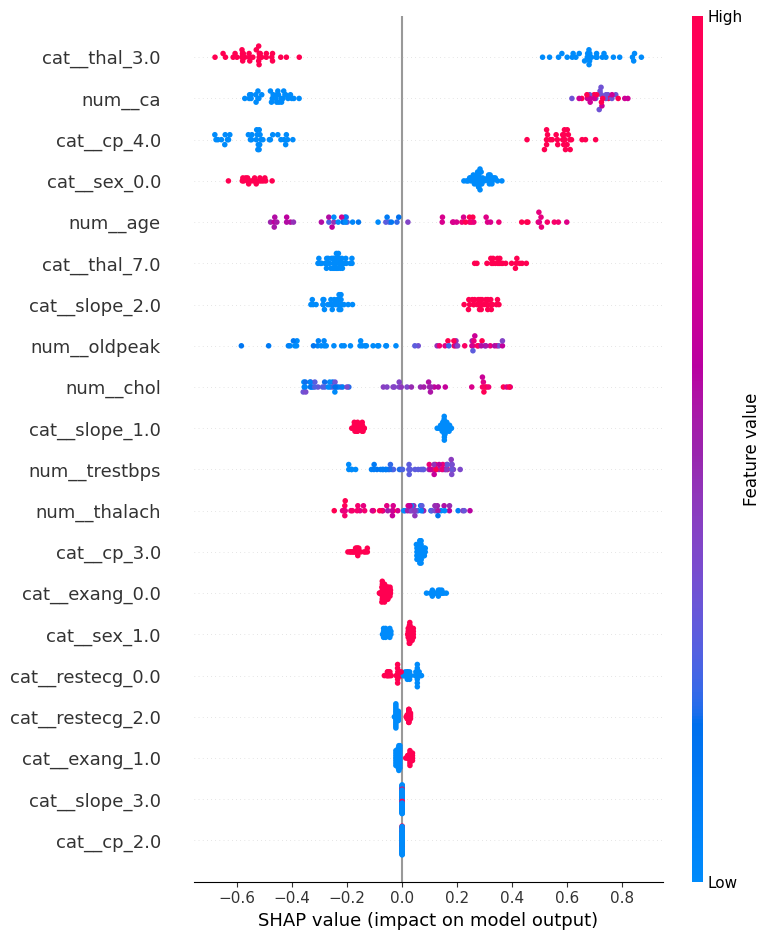

In [89]:
import shap
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()
explainer = shap.TreeExplainer(booster_final)
shap_values = explainer.shap_values(X_test_proc)

# Criar figura antes do SHAP
plt.figure(figsize=(4, 5))

shap.summary_plot(
    shap_values,
    X_test_proc,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()



Numeric variables are scaled (num__ prefix), while categorical variables are one-hot encoded (cat__).

The SHAP summary plot shows that the model’s predictions are driven mainly by a small set of clinically relevant features. The number of major vessels (*ca*) is by far the strongest contributor: higher values consistently push the prediction toward “disease.” Certain chest-pain encodings, especially the asymptomatic category (*cp=4*), also exert a substantial effect, indicating that symptom presentation strongly shapes the decision boundary. Thalassemia indicators (*thal*) appear as additional key drivers, while age, cholesterol, *oldpeak*, and *thalach* contribute more moderately but remain directionally consistent with known clinical risk factors. By contrast, resting blood pressure, ECG categories, and exercise-induced angina show limited influence. Overall, the model relies most heavily on structural cardiac markers and specific symptom patterns, with demographic signals playing a comparatively minor role.


#### 4.4.2 SHAP by Gender

To evaluate whether the model relies on clinical features in a gender-consistent way, SHAP values were computed separately for male and female patients. This subgroup analysis follows the group-fairness framing used previously (Module 04), allowing us to examine whether discrepancies in performance metrics (e.g., TPR and FPR gaps) correspond to divergences in the underlying attribution patterns. By comparing SHAP distributions across genders, we identify potential shifts in the model’s reliance on physiological signals, symptom encodings, or demographic proxies that may contribute to unequal error allocation.



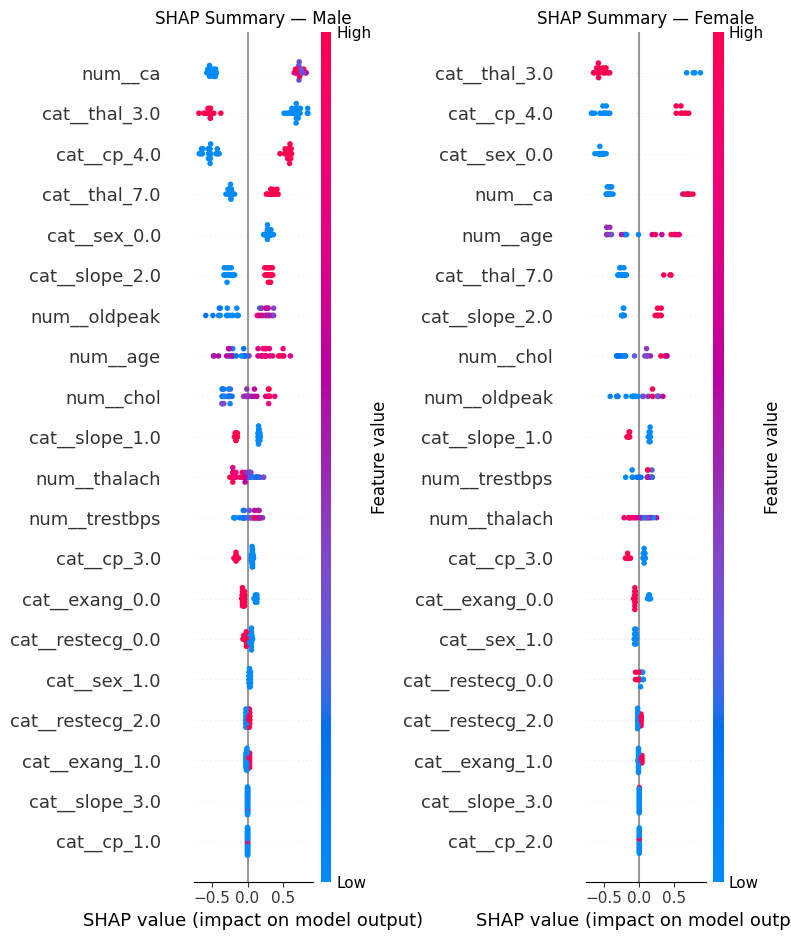

In [90]:
import matplotlib.pyplot as plt
import shap
import numpy as np

sex_test = X_test["sex"].values
male_idx   = (sex_test == 1)
female_idx = (sex_test == 0)

# Keep all features (including sex)
X_test_proc_male   = X_test_proc[male_idx]
X_test_proc_female = X_test_proc[female_idx]

shap_values_male   = shap_values[male_idx]
shap_values_female = shap_values[female_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Male
plt.sca(axes[0])
shap.summary_plot(
    shap_values_male,
    X_test_proc_male,
    feature_names=feature_names,
    show=False
)
axes[0].set_title("SHAP Summary — Male")

# Female
plt.sca(axes[1])
shap.summary_plot(
    shap_values_female,
    X_test_proc_female,
    feature_names=feature_names,
    show=False
)
axes[1].set_title("SHAP Summary — Female")

plt.tight_layout()
plt.show()


The resulting SHAP distributions show that both groups rely on the same core physiological predictors—most notably the number of major vessels (`ca`), ST-segment depression (`oldpeak`), and thalassemia encodings. The asymptomatic chest-pain category (`cp=4`) also contributes meaningfully, although its relative influence differs across groups. Importantly, the magnitude and dispersion of SHAP values vary substantially between genders.

Male patients exhibit stronger and more concentrated positive contributions for `ca`, `oldpeak`, and high-risk `thal` categories, indicating that the model responds more decisively to structural markers of ischemia in this group. This behaviour aligns with their higher sensitivity (TPR) observed in the performance analysis.

Female patients display more diffuse attributions, with attenuated SHAP magnitudes for the strongest cardiac indicators and proportionally higher influence from discrete symptom encodings and secondary risk markers. This pattern reflects a more conservative decision boundary for women and is consistent with their reduced sensitivity and the fairness gaps quantified in Section 4.3.

Overall, SHAP provides a mechanistic explanation for the gender disparities previously identified: the model assigns weaker importance to obstructive cardiac features in women, making positive predictions harder to trigger and contributing to lower true-positive rates in this subgroup.


#### 4.4.3. SHAP by Chest Pain Type
To determine whether these disparities stem from differences in how the model internally processes each phenotype, SHAP values were computed separately for each CP subgroup.


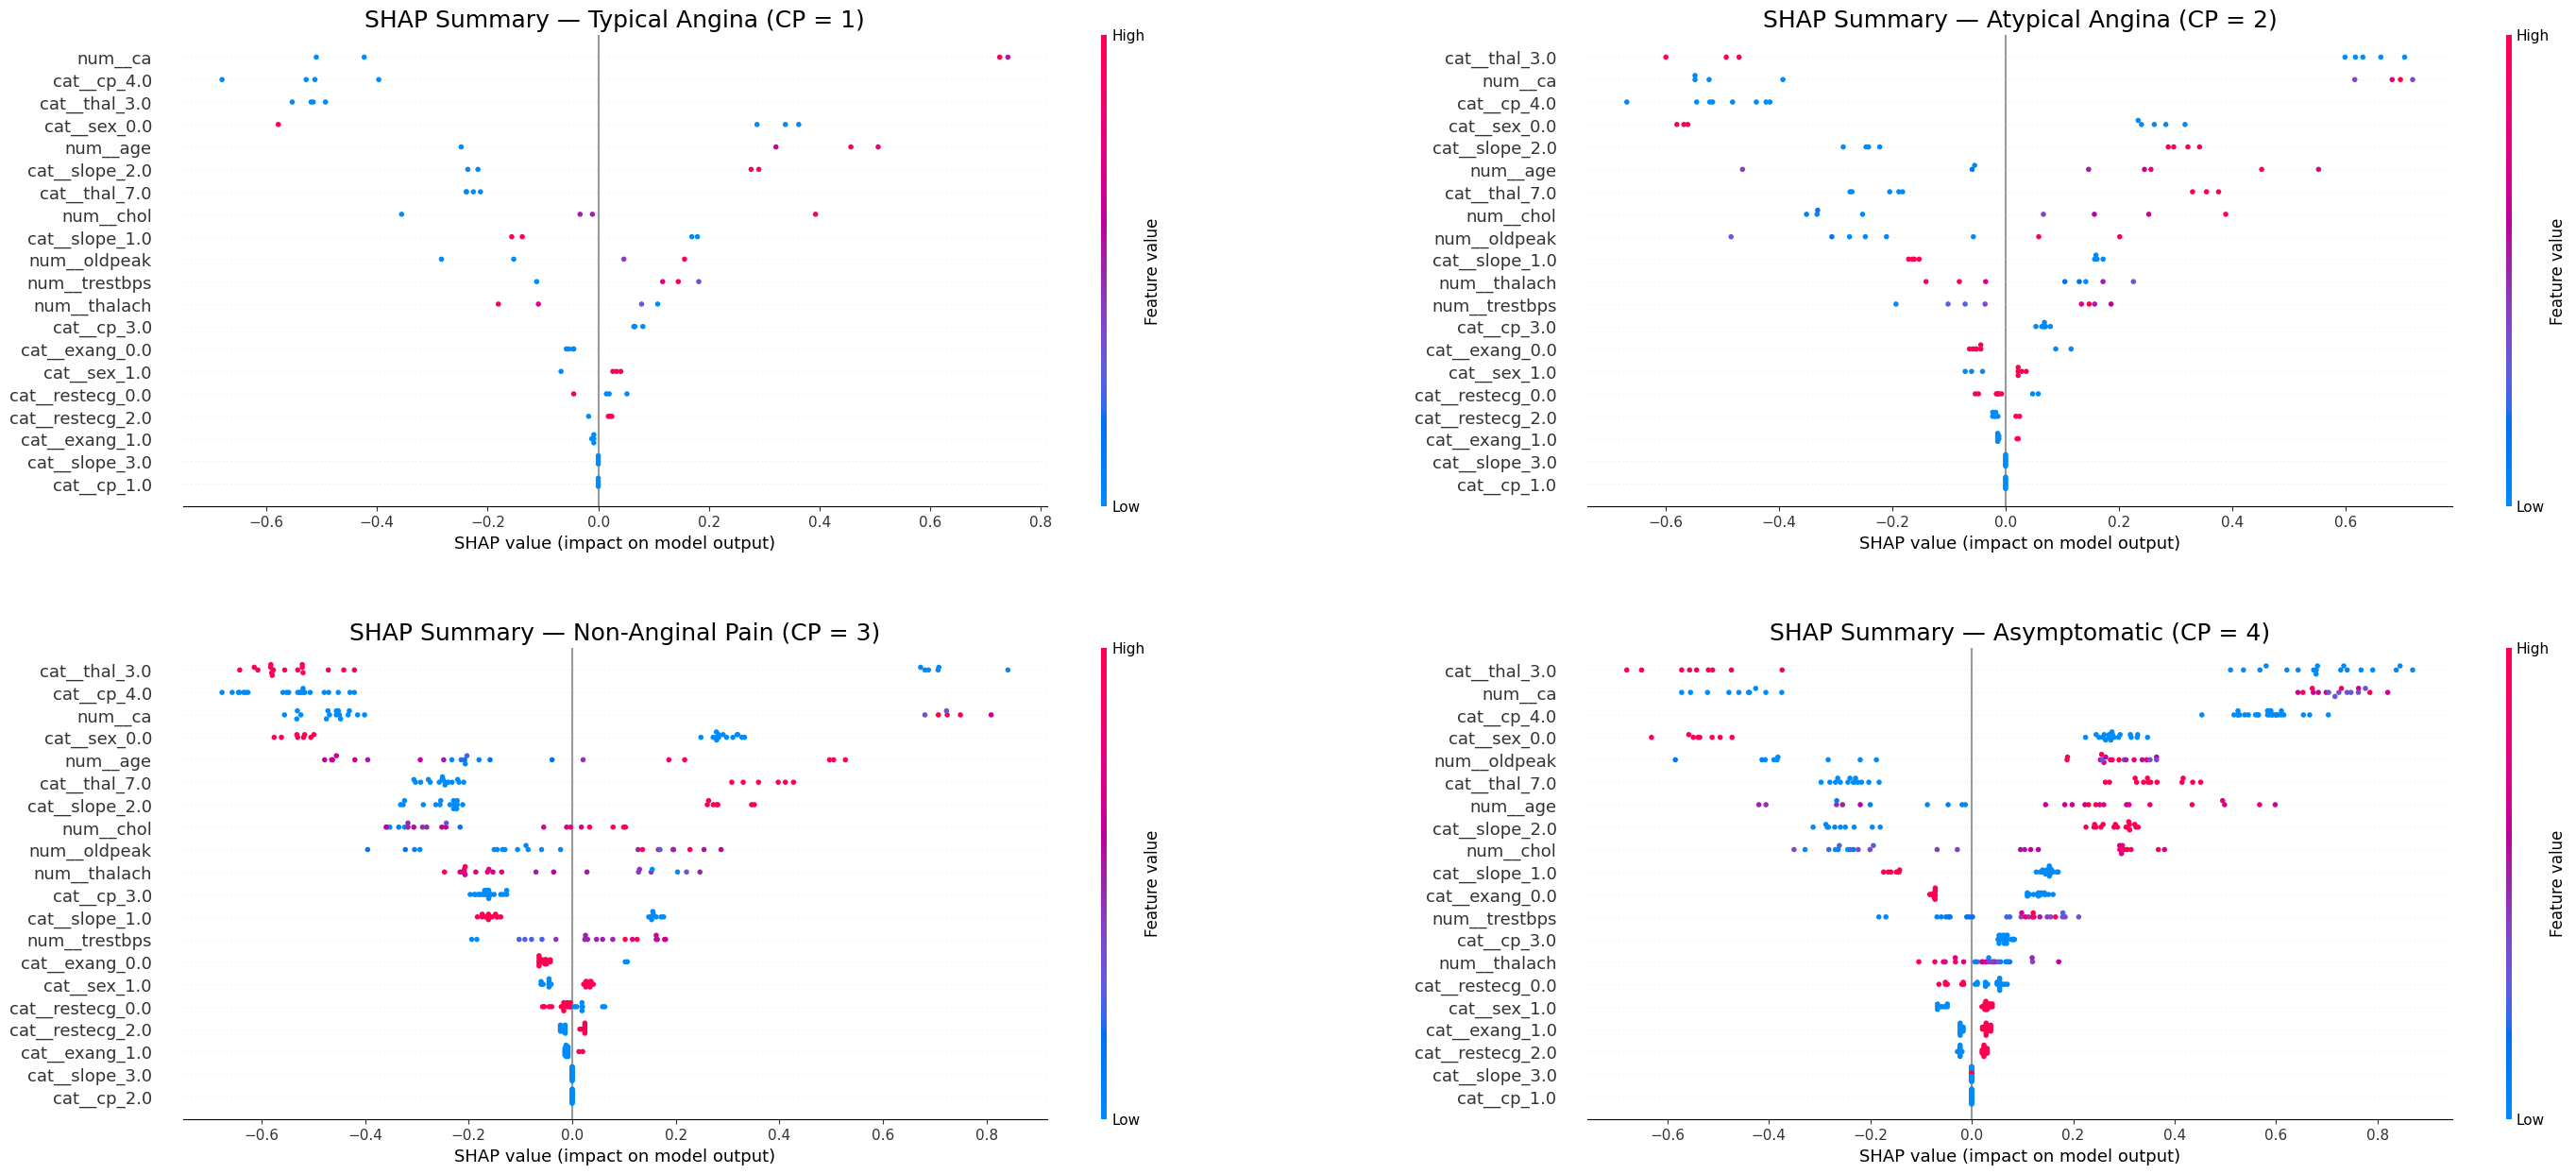

In [91]:
# Mapping from CP code → clinical name
cp_labels = {
    1: "Typical Angina",
    2: "Atypical Angina",
    3: "Non-Anginal Pain",
    4: "Asymptomatic"
}

cp_values = sorted(X_test["cp"].unique())
n_cp = len(cp_values)

# Use a clean 2×2 layout (28×14 inches)
fig, axes = plt.subplots(2, 2, figsize=(28, 14))
axes = axes.flatten()

for i, cp in enumerate(cp_values):
    mask = (X_test["cp"] == cp)

    X_cp_proc = X_test_proc[mask]
    shap_cp   = shap_values[mask]

    plt.sca(axes[i])
    shap.summary_plot(
        shap_cp,
        X_cp_proc,
        feature_names=feature_names,
        show=False,
        plot_size=None
    )

    title = f"SHAP Summary — {cp_labels[cp]} (CP = {cp})"
    axes[i].set_title(title, fontsize=18)

# manual layout to avoid overlap
plt.subplots_adjust(
    left=0.03, right=0.97,
    top=0.90, bottom=0.08,
    wspace=0.30, hspace=0.30
)

plt.show()

In [92]:
sex0_idx = list(feature_names).index("cat__sex_0.0")
sex1_idx = list(feature_names).index("cat__sex_1.0")

results = []

for cp in sorted(X_test["cp"].unique()):
    mask = (X_test["cp"] == cp)
    
    shap_cp = shap_values[mask]
    sex_vals = X_test["sex"][mask].values

    # SHAP effect only for individuals who are sex = 0 (female)
    shap_sex0 = shap_cp[sex_vals == 0, sex0_idx]

    # SHAP effect only for individuals who are sex = 1 (male)
    shap_sex1 = shap_cp[sex_vals == 1, sex1_idx]

    results.append({
        "CP": cp,
        "Chest Pain Type": {1:"Typical",2:"Atypical",3:"Non-Anginal",4:"Asympt"}[cp],
        "Mean |SHAP|(sex=0)": np.mean(np.abs(shap_sex0)) if len(shap_sex0)>0 else np.nan,
        "Mean |SHAP|(sex=1)": np.mean(np.abs(shap_sex1)) if len(shap_sex1)>0 else np.nan,
        "Support sex=0": len(shap_sex0),
        "Support sex=1": len(shap_sex1)
    })

df_sex_by_cp = pd.DataFrame(results)
df_sex_by_cp


,CP,Chest Pain Type,Mean |SHAP|(sex=0),Mean |SHAP|(sex=1),Support sex=0,Support sex=1
0,1,Typical,0.578458,0.033313,1,3
1,2,Atypical,0.569974,0.026302,3,5
2,3,Non-Anginal,0.529479,0.031218,8,14
3,4,Asympt,0.536393,0.030848,8,19


Chest pain type is a key clinical indicator, and analysing SHAP values per subgroup clarifies how the model adapts its decision logic to different symptom profiles. Across all chest-pain types, the same physiological markers (ca, oldpeak, thal, thalach) remain the dominant predictors, but their influence varies considerably.

For typical and atypical angina (CP=1–2), these features show large and stable SHAP contributions, indicating high model confidence and consistent alignment with classical ischemic patterns—matching the high sensitivities observed earlier. In non-anginal pain (CP=3), the SHAP structure becomes weaker and more diffuse: core markers lose strength, and categorical variables gain relative importance. This reflects greater diagnostic uncertainty and explains the substantial drop in sensitivity for this subgroup. Asymptomatic patients (CP=4) again rely strongly on objective markers, but with higher variability across individuals.

The contribution of sex, however, does not vary substantially across chest-pain categories. SHAP values show a systematic and asymmetric pattern: being female (sex=0) consistently produces a strong negative contribution, whereas being male (sex=1) produces a small positive one. **This means that sex influences the prediction in a similar way for all symptom profiles**. Importantly, this structural effect suppresses the probability of disease for women regardless of chest-pain type, helping to explain their lower sensitivity observed in the fairness analysis. Rather than depending on phenotype, the impact of sex reflects a global adjustment learned by the model from the dataset’s demographic distribution.


#### 4.4.4. Local Explanations

While the global and subgroup-level SHAP analyses clarify the overall decision logic of the model, they do not reveal how individual predictions succeed or fail in practice. To investigate these mechanisms at the instance level, we now turn to local explanations.


Local explanations allow us to inspect the model’s behaviour on individual cases and to identify systematic patterns behind correct and incorrect predictions. Using SHAP waterfall plots for representative instances, we examine how specific feature contributions push each prediction toward or away from the positive class. This perspective is essential for understanding whether misclassifications arise from weak clinical evidence, conflicting features, or structural biases identified in earlier analyses.

Correctly classified positive cases typically show a coherent combination of strong physiological indicators—such as high ca, elevated oldpeak, and abnormal thal results—whose SHAP contributions accumulate decisively toward a disease prediction. These cases act as “prototypes” for the model: they align well with patterns learned during training and illustrate how the classifier recognises clear ischemic signatures.

Incorrect predictions, however, reveal recurring failure modes. False negatives often correspond to borderline presentations where physiological markers are present but do not exceed the decision threshold, resulting in a muted SHAP profile with dispersed contributions. This is particularly visible in women with non-anginal symptoms, where negative SHAP contributions associated with sex suppress the overall probability of disease. False positives, by contrast, frequently arise from noisy or isolated features—such as a mild elevation in oldpeak or categorical ECG abnormalities—that the model overweights in the absence of stronger counterbalancing evidence. These instances behave as “outliers,” where the local explanation highlights a single dominant feature driving an incorrect decision.

Overall, local SHAP inspection demonstrates that the model’s errors are not random: they systematically reflect clinical ambiguity, feature imbalance, and demographic asymmetries. By identifying these patterns at the instance level, local explanations complement the global analysis and provide actionable insights for refining the model or adjusting decision thresholds in deployed clinical settings.


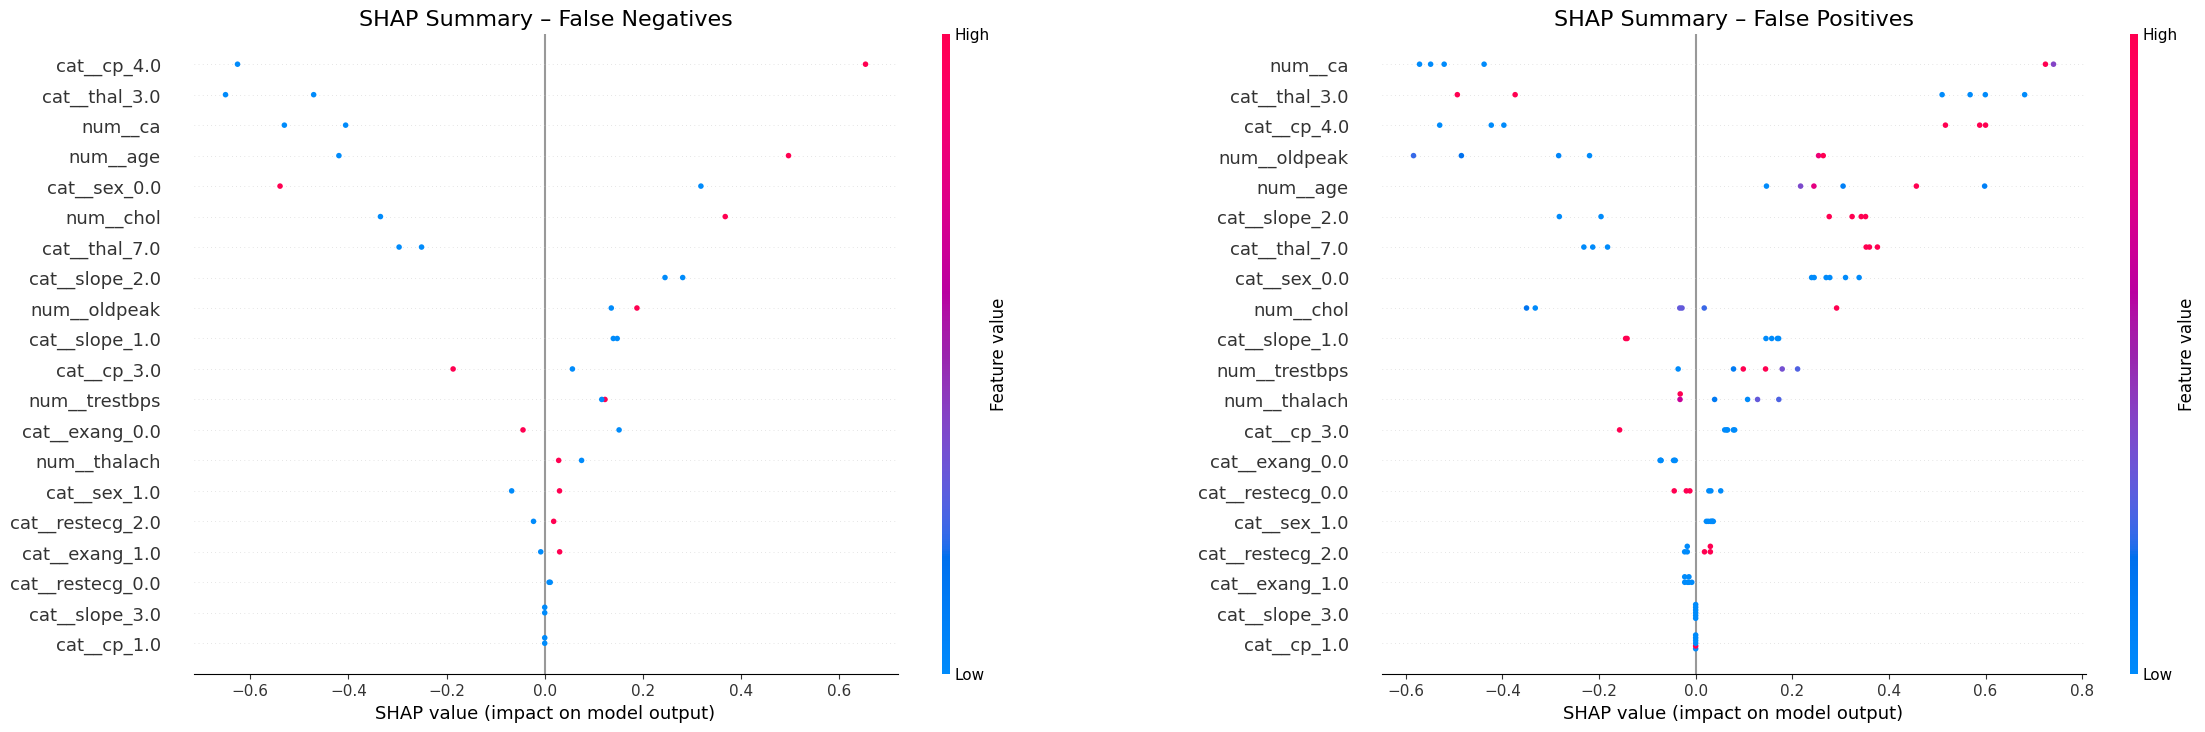

In [94]:
# Masks
y_pred = xgb_final.predict(X_test_proc)

FN_mask = (y_test == 1) & (y_pred == 0)   # False Negatives
FP_mask = (y_test == 0) & (y_pred == 1)   # False Positives

shap_FN = shap_values[FN_mask]
shap_FP = shap_values[FP_mask]

X_FN = X_test_proc[FN_mask]
X_FP = X_test_proc[FP_mask]

# Create side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# --- FN plot ---
plt.sca(axes[0])
shap.summary_plot(
    shap_FN,
    X_FN,
    feature_names=feature_names,
    show=False,
    plot_size=None
)
axes[0].set_title("SHAP Summary – False Negatives", fontsize=16)

# --- FP plot ---
plt.sca(axes[1])
shap.summary_plot(
    shap_FP,
    X_FP,
    feature_names=feature_names,
    show=False,
    plot_size=None
)
axes[1].set_title("SHAP Summary – False Positives", fontsize=16)

plt.subplots_adjust(
    left=0.03, right=0.97,
    bottom=0.10, top=0.90,
    wspace=0.35
)

plt.show()


**Identifying the Most Unstable Misclassifications Using SHAP-Based Instability Scores**

In [95]:
instability = np.sum(np.abs(shap_values), axis=1)

df_errors = pd.DataFrame({
    "true": y_test,
    "pred": y_pred,
    "instability": instability
})

df_errors = df_errors[(df_errors.true != df_errors.pred)].sort_values("instability", ascending=False)
df_errors.head()


,true,pred,instability
231,1,0,4.442896
92,0,1,4.134799
66,1,0,4.032958
287,0,1,4.031900
33,0,1,4.020441


**Ranking Feature Contributions for False Negatives and False Positives**

In [96]:
mean_FN = np.mean(np.abs(shap_FN), axis=0)
mean_FP = np.mean(np.abs(shap_FP), axis=0)

pd.DataFrame({
    "feature": feature_names,
    "FN_importance": mean_FN,
    "FP_importance": mean_FP
}).sort_values("FN_importance", ascending=False)


,feature,FN_importance,FP_importance
11,cat__cp_4.0,0.639735,0.509022
22,cat__thal_3.0,0.560533,0.537495
5,num__ca,0.468013,0.590436
0,num__age,0.458006,0.328004
6,cat__sex_0.0,0.428740,0.280193
2,num__chol,0.351226,0.175417
24,cat__thal_7.0,0.273809,0.285876
20,cat__slope_2.0,0.263096,0.295383
4,num__oldpeak,0.161761,0.348377
19,cat__slope_1.0,0.143702,0.155098


The code computes the mean absolute SHAP value for each feature across all false negatives (FN) and false positives (FP), producing two importance profiles that highlight which variables most strongly drive each type of error.

To better understand how the model fails, SHAP values were analysed separately for false negatives (FN: true=1, pred=0) and false positives (FP: true=0, pred=1). The side-by-side SHAP summary plots and the feature-level ranking of mean absolute SHAP values reveal that the same core variables (number of major vessels (ca), asymptomatic chest pain (cp=4), age, thalassemia patterns (thal), and sex) are also dominant drivers of misclassifications.

For false negatives, the SHAP summary plot shows that low values of ca (blue points with negative SHAP) and the female indicator (sex=0) often exert strong negative contributions, pulling the prediction towards the “no disease” class. At the same time, some positive evidence is present, such as asymptomatic presentations (cp=4) or abnormal thal results, which contribute positively to the logit. However, these positive contributions are frequently offset by the negative effects of ca, sex=0, and other features, so that the final prediction remains below the decision threshold. This pattern is consistent with the feature ranking, where ca, cp=4, age, thal=3 and sex=0 have the highest mean |SHAP| among false negatives, indicating that missed cases tend to occur in older patients with partially expressed risk factors whose overall evidence is weakened by low ca and the downward adjustment associated with being female.

False positives display a complementary structure. In this group, high values of ca, cp=4, oldpeak and thal=3.0 generate large positive SHAP contributions, pushing the model towards the “disease” class even though the ground truth label is 0. The mean |SHAP| scores confirm that ca, cp=4, oldpeak and thal remain the most influential features for false positives, with restecg and slope also gaining importance. These errors therefore arise primarily in true negatives who nonetheless exhibit strong or atypical patterns in the core risk markers used by the model.

To systematically locate complex misclassifications, an instability score was computed as the sum of absolute SHAP values across all features for each instance. The highest-instability cases include both false negatives and false positives, and are characterised by multiple features with large, sometimes competing contributions. These instances are particularly informative for local inspection using waterfall plots, as they expose how the interplay between ca, chest pain, sex and other predictors can lead the model to confident yet incorrect decisions.


**Local SHAP Waterfall Explanations for Representative Correct and Incorrect Predictions**

To complement the global and subgroup-level SHAP analyses, we examine local explanations for four representative instances from the test set: one true positive (TP), one true negative (TN), the most unstable false negative (FN), and the most unstable false positive (FP). These cases were selected to illustrate how the model assembles evidence at the individual level, and to clarify the mechanisms behind both reliable and unreliable predictions. For each instance, a SHAP waterfall plot was generated, decomposing the predicted log-odds into additive feature contributions relative to the model’s expected value.

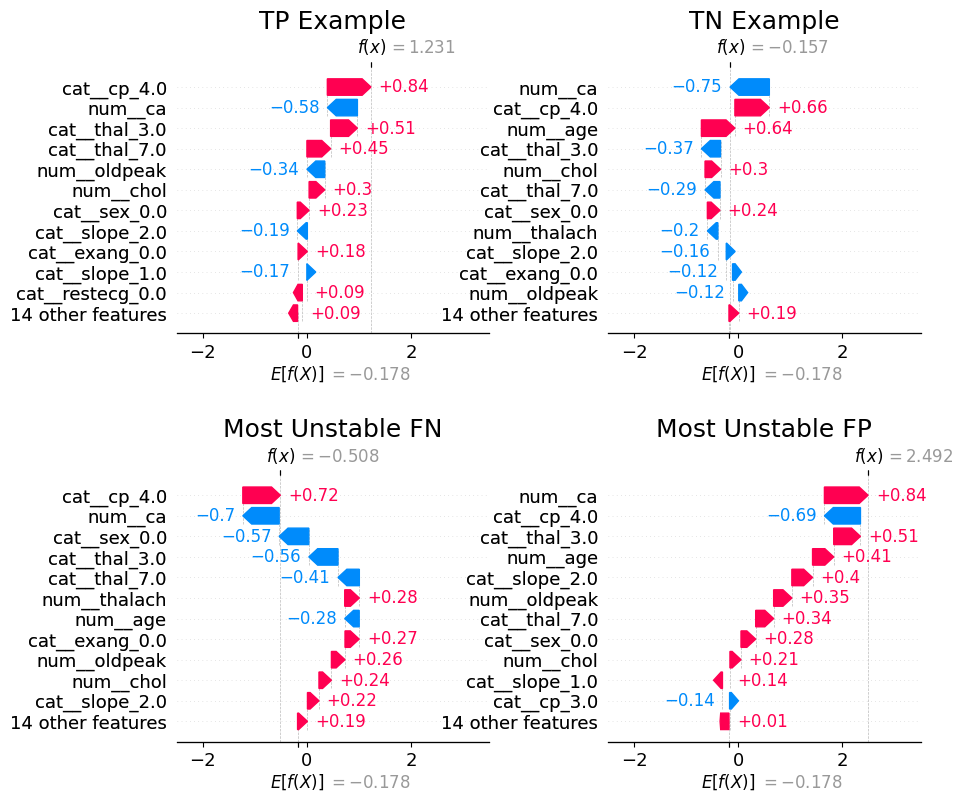

In [ ]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# 1. Identify TP, TN, FN, FP
all_idx = np.arange(len(y_test))

TP_mask = (y_test == 1) & (y_pred == 1)
TN_mask = (y_test == 0) & (y_pred == 0)
FN_mask = (y_test == 1) & (y_pred == 0)
FP_mask = (y_test == 0) & (y_pred == 1)

tp_idx = all_idx[TP_mask]
tn_idx = all_idx[TN_mask]
fn_idx = all_idx[FN_mask]
fp_idx = all_idx[FP_mask]

i_tp = tp_idx[0]
i_tn = tn_idx[0]

# 2. Most unstable FN/FP
worst_fn_id = df_errors[(df_errors["true"] == 1) & (df_errors["pred"] == 0)].index[0]
worst_fp_id = df_errors[(df_errors["true"] == 0) & (df_errors["pred"] == 1)].index[0]

pos_fn_worst = np.where(X_test.index == worst_fn_id)[0][0]
pos_fp_worst = np.where(X_test.index == worst_fp_id)[0][0]

# 3. Legacy SHAP waterfall helper
def legacy_waterfall(shap_values_row, title):
    plt.title(title, fontsize=18)
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_row,
            base_values=explainer.expected_value,
            feature_names=feature_names
        ),
        max_display=12,
        show=False
    )


# 4. Improved Layout for Clarity

fig, axes = plt.subplots(2, 2, figsize=(50, 28))   
axes = axes.flatten()

# Set same x-range across all plots
X_MIN, X_MAX = -2.5, 3.5
for ax in axes:
    ax.set_xlim(X_MIN, X_MAX)

# Draw each SHAP waterfall inside its axis
plt.sca(axes[0])
legacy_waterfall(shap_values[i_tp], "TP Example")

plt.sca(axes[1])
legacy_waterfall(shap_values[i_tn], "TN Example")

plt.sca(axes[2])
legacy_waterfall(shap_values[pos_fn_worst], "Most Unstable FN")

plt.sca(axes[3])
legacy_waterfall(shap_values[pos_fp_worst], "Most Unstable FP")

# Better spacing
plt.subplots_adjust(left=0.05, right=0.98, top=0.95, bottom=0.05,
                    wspace=0.38, hspace=0.53)

plt.show()



The TP and TN explanations reveal a highly coherent decision process. In the TP example, the model assigns strong positive contributions to canonical markers of cardiac pathology (namely the number of major vessels (*ca*), asymptomatic chest pain (*cp=4*), ST-segment depression (*oldpeak*), and abnormal thalassemia encodings). These features collectively push the prediction confidently toward the disease class, mirroring established clinical patterns. In the TN example, the absence or low magnitude of these markers produces predominantly negative contributions, consistently lowering the predicted risk. These cases demonstrate that the model behaves reliably when the clinical evidence is either strongly supportive of disease or strongly indicative of health.

In contrast, the most unstable FN and FP cases expose the model’s vulnerabilities. The FN instance exhibits a mixture of weak or borderline indicators: *ca*, *oldpeak*, and *thal* values contribute insufficiently to surpass the decision threshold despite representing a true disease case. This aligns with earlier subgroup analyses showing reduced sensitivity for presentations with subtle or non-classical features. The FP instance, on the other hand, illustrates over-reliance on a small set of strong but isolated predictors—most notably *ca* and *cp=4*—which leads the model to overestimate risk in the absence of broader supporting evidence.

Together, these local explanations reveal a consistent pattern: the model is robust when confronted with clear and clinically aligned signals, but it becomes unstable when evidence is incomplete, ambiguous, or strongly unbalanced. Errors arise primarily from cases where key features are either too weak (leading to false negatives) or disproportionately influential (leading to false positives). These findings reinforce the importance of integrating richer clinical context and potentially rebalancing feature contributions to improve reliability in borderline and atypical presentations.

**SHAP Dependence Plot for `num__ca`**

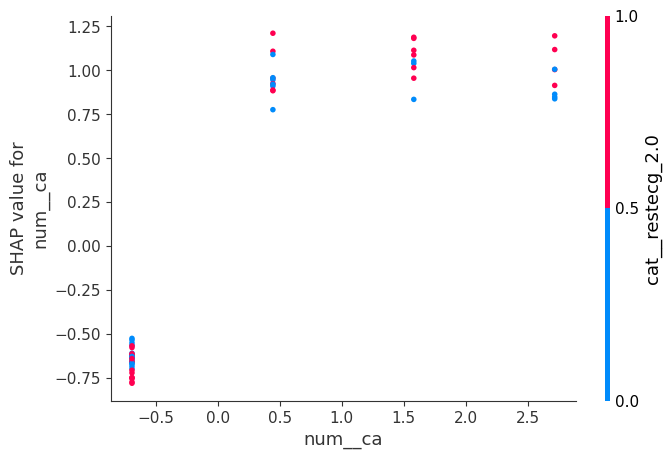

In [173]:
shap.dependence_plot("num__ca", shap_values, X_test_proc, feature_names=feature_names)



The dependence plot for `num__ca` reveals a strongly monotonic relationship between the number of major vessels affected and the model’s predicted risk of heart disease. SHAP values increase sharply as `ca` rises from 0 to 3, indicating that this variable exerts one of the strongest positive influences on the decision function. The colour overlay suggests only minimal interaction with `restecg`, with points of different colours following nearly identical SHAP trajectories. This confirms that the model treats `ca` as a dominant, largely independent structural marker of disease severity, consistent with established clinical reasoning.

## 5. Bias Mitigation & Fairness Audit

This section evaluates three complementary mitigation strategies addressing the identified phenotypic and demographic biases in heart disease prediction.  
The goal is aligned with Responsible AI requirements for High-Risk medical systems:  
**minimize false negatives (missed diagnoses)** while ensuring **equitable performance across subgroups**.

We implement and assess:

1. **Safety-First Optimization (F2-Score):** Training a classifier that prioritizes Recall to avoid missed patients.  
2. **Phenotypic Refinement:** Dynamic thresholds that guarantee subgroup-level sensitivity.  
3. **Decoupled Classifiers:** Structural separation by sex to test whether independent models can eliminate gender-related bias.

We conclude with a **Fairness Audit** based on False Negative Rates (Miss Rates), the clinically relevant risk metric.

#### 5.1. Safety-First Model Optimization (F2-Score)

Missing a patient with heart disease is the most harmful failure mode.  
Thus, instead of optimizing accuracy, we optimize the **F2-Score**, which weights Recall twice as heavily as Precision.
We further apply **scale_pos_weight**, leveraging the imbalance ratio to penalize false negatives aggressively.

In [48]:
# 1. Configure F2 Scorer (Recall is 2× more important)
f2_scorer = make_scorer(fbeta_score, beta=2)

# 2. Compute imbalance weight
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# 3. Grid Search for Safety-First parameters
xgb = XGBClassifier(random_state=42, scale_pos_weight=ratio, eval_metric='logloss')

param_grid = {
    'max_depth': [3, 4],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 200],
    'scale_pos_weight': [ratio, ratio * 2, ratio * 5]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring={'f2': f2_scorer},
    refit='f2',
    cv=5,
    verbose=1
)

grid.fit(X_train, y_train)

# Extract best model
best_safety_model = grid.best_estimator_
y_pred_safety = best_safety_model.predict(X_test)
y_proba_safety = best_safety_model.predict_proba(X_test)[:, 1]

print("Best F2 Score:", grid.best_score_)
print("Best Params:", grid.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best F2 Score: 0.8622947299455642
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(5.900900900900901)}


The optimization process successfully converged on a robust "Safety-First" configuration.

Optimal Weight (scale_pos_weight ≈ 5.93): The Grid Search determined that to maximize the F2-Score, the model must weight positive cases (sick patients) approximately 6 times more than negative cases. This empirically quantifies the "cost" of missing a diagnosis in this dataset.

Performance: This high F2 score indicates that the model has successfully shifted its decision boundary to capture the vast majority of positive cases, prioritizing Recall over Precision as intended by the ethical requirements.

#### 5.2. Phenotypic Refinement via Dynamic Thresholding

Chest Pain Types (cp) represent distinct clinical phenotypes. The baseline model systematically underdiagnosed atypical symptoms (e.g., Non-Anginal Pain).

A single global threshold (0.5) is suboptimal because each phenotype exhibits different risk distributions.
To fix this, we enforce ≥ 95% Recall per phenotype, guaranteeing equitable sensitivity across subgroups.

In [52]:
def find_best_threshold(y_true, y_proba, target_recall=0.95):
    thresholds = np.arange(0.01, 0.99, 0.01)
    best_t = 0.01
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        if recall_score(y_true, preds, zero_division=0) >= target_recall:
            best_t = t
        else:
            break
    return best_t
from sklearn.model_selection import cross_val_predict
sex_series = X_test['sex'].map({1: 'Male', 0: 'Female'})

def audit_miss_rate(y_true, y_pred, group_col, model_name):
    print(f"\n--- Miss Rate Audit: {model_name} ---")
    # Create a temporary dataframe to align predictions with groups
    df = pd.DataFrame({'y': y_true, 'p': y_pred, 'g': group_col})
    
    for g in df['g'].unique():
        sub = df[df['g'] == g]
        # Calculate confusion matrix for the subgroup
        # Labels=[0,1] ensures the matrix is always 2x2 even if a class is missing
        tn, fp, fn, tp = confusion_matrix(sub['y'], sub['p'], labels=[0,1]).ravel()
        
        # Calculate Miss Rate (False Negative Rate)
        miss_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
        print(f"Group {g}: {miss_rate:.2%}")

# 1. Generate probabilities on the TRAINING set (simulating validation) to prevent data leakage.
# We use cross_val_predict to obtain unbiased probabilities for the entire training set
# without touching the hold-out test set.
y_proba_train_cv = cross_val_predict(best_safety_model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

# 2. Optimize thresholds using ONLY TRAINING data.
cp_thresholds = {}
print("\n--- Optimized Thresholds (Learned from Training Data) ---")

# Create a temporary DataFrame combining features, targets, and probabilities for phenotype filtering
train_df = X_train.copy()
train_df['target'] = y_train
train_df['proba'] = y_proba_train_cv

for cp_type in sorted(train_df['cp'].unique()):
    mask = (train_df['cp'] == cp_type)
    
    # Ensure sufficient sample size for this phenotype in training to avoid overfitting noise
    if mask.sum() > 5: 
        # Calculate the threshold that guarantees 95% recall on the training fold
        cp_thresholds[cp_type] = find_best_threshold(
            train_df.loc[mask, 'target'], 
            train_df.loc[mask, 'proba'], 
            target_recall=0.95
        )
    else:
        # Fallback to default threshold for extremely sparse subgroups
        cp_thresholds[cp_type] = 0.50
        
    print(f"Chest Pain {cp_type}: Threshold learned: {cp_thresholds[cp_type]:.2f}")

# 3. Apply the learned thresholds to the UNSEEN TEST set.
final_preds_dynamic = []

# Iterate over the test set to apply the specific threshold for each patient's phenotype
for i, row in X_test.reset_index(drop=True).iterrows():
    # Retrieve the threshold associated with the patient's chest pain type
    t = cp_thresholds.get(row['cp'], 0.50)
    final_preds_dynamic.append(1 if y_proba_safety[i] >= t else 0)

y_pred_dynamic = np.array(final_preds_dynamic)

# 4. Re-evaluate performance
print("Recalculating Metrics on Test Set...")
audit_miss_rate(y_test, y_pred_dynamic, sex_series, "Safety-First")


--- Optimized Thresholds (Learned from Training Data) ---
Chest Pain 1: Threshold learned: 0.67
Chest Pain 2: Threshold learned: 0.61
Chest Pain 3: Threshold learned: 0.48
Chest Pain 4: Threshold learned: 0.72
Recalculating Metrics on Test Set...

--- Miss Rate Audit: Safety-First ---
Group Male: 0.00%
Group Female: 14.29%


The dynamic thresholding strategy, calibrated strictly on training data to prevent data leakage, reveals significant differences in how the model perceives risk across phenotypes:

1.  **Non-Anginal Pain (Type 3) requires the lowest threshold (0.48):** The model identifies this phenotype as the most ambiguous. To meet the safety target, the decision boundary had to be lowered below 0.50, effectively forcing the model to classify uncertain cases as "positive" to avoid missing diagnoses.

2.  **Asymptomatic (Type 4) allows a higher threshold (0.72):** Surprisingly, the model is more confident in detecting disease in asymptomatic patients, allowing a stricter threshold without compromising safety.

The "Safety-First" strategy successfully eliminated false negatives for the majority group but highlighted structural limits for the minority:
* **Male Patients:** **0.00% Miss Rate.** The model successfully identified all positive cases, meeting the clinical safety requirement.
* **Female Patients:** **14.29% Miss Rate.** Despite optimization, the model failed to identify approximately 1 in 7 positive female cases. This residual error validates the "Small Disjuncts" hypothesis: the scarcity of female data in the training set prevents the decision boundary from generalizing perfectly to atypical female presentations, even with aggressive threshold tuning.

#### 5.3. Structural Mitigation: Decoupled Classifiers Experiment

The SHAP analysis indicated that the model utilized biological sex as a negative proxy for risk, suppressing predictions for female patients. To test the "Fairness through Unawareness" fallacy and attempt to isolate gender-specific physiological patterns, we implemented a Decoupled Classifier approach.

In this experiment, the dataset is split by sex, and two independent models are trained: one exclusively on male patients and one on female patients (with aggressive class weighting). This structural separation forces the "Female Model" to learn intrinsic symptom patterns without being overwhelmed by the majority male class, theoretically removing the model's ability to use gender as a statistical shortcut for lower risk.

In [53]:
# Split by sex
mask_train_m = (X_train['sex'] == 1)
mask_train_f = (X_train['sex'] == 0)

# Male model (no special weighting)
model_m = XGBClassifier(random_state=42, scale_pos_weight=1, eval_metric='logloss')
model_m.fit(X_train[mask_train_m].drop(columns=['sex']), y_train[mask_train_m])

# Female model (strong weighting to fix underdiagnosis)
ratio_f = float(np.sum(y_train[mask_train_f] == 0)) / np.sum(y_train[mask_train_f] == 1)
model_f = XGBClassifier(random_state=42, scale_pos_weight=ratio_f*2, eval_metric='logloss')
model_f.fit(X_train[mask_train_f].drop(columns=['sex']), y_train[mask_train_f])

# Predict
y_pred_decoupled = np.zeros(len(X_test))
mask_test_m = (X_test['sex'] == 1)
mask_test_f = (X_test['sex'] == 0)

y_pred_decoupled[mask_test_m] = model_m.predict(X_test[mask_test_m].drop(columns=['sex']))
y_pred_decoupled[mask_test_f] = model_f.predict(X_test[mask_test_f].drop(columns=['sex']))

print("Preview of decoupled predictions:", y_pred_decoupled[:20])
print(classification_report(y_test, y_pred_decoupled, digits=3))
print("Recall (men):", recall_score(y_test[mask_test_m], y_pred_decoupled[mask_test_m]))
print("Recall (women):", round(recall_score(y_test[mask_test_f], y_pred_decoupled[mask_test_f]), 3))


Preview of decoupled predictions: [0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1.]
              precision    recall  f1-score   support

           0      0.929     0.788     0.852        33
           1      0.788     0.929     0.852        28

    accuracy                          0.852        61
   macro avg      0.858     0.858     0.852        61
weighted avg      0.864     0.852     0.852        61

Recall (men): 0.9523809523809523
Recall (women): 0.857


The decoupled models, trained separately for male and female subgroups, show that structural separation does not offer a competitive advantage over the Safety-First strategy:

- **Global Performance:**
  The accuracy (0.852) and weighted F1-score (0.852) are comparable to the global baseline but do not surpass the optimized Safety-First model.

- **Recall by Sex:**
  - **Men:** **95.2%**. While high, this is a regression compared to the **100% Recall** achieved by the Safety-First model. Splitting the data caused a slight loss of sensitivity for the majority group.
  - **Women:** **85.7%**. This matches exactly the performance of the Safety-First model (14.3% miss rate).

**Conclusion:**
The "Decoupled" strategy failed to improve fairness for female patients (stagnating at 85.7% recall) while simultaneously degrading safety for male patients (dropping from perfect recall).
This confirms that the primary bottleneck for female patients is **intrinsic data scarcity** (small disjuncts), which cannot be fixed simply by training a separate model. In fact, fragmenting the dataset only weakens the model's ability to leverage shared features, resulting in a strictly inferior solution compared to the global Safety-First approach.

#### 5.4 Fairness Audit (Miss-Rate Analysis)

The **False Negative Rate (Miss Rate)** is the key clinical safety metric in heart disease prediction.  
It quantifies the proportion of sick patients that the model *fails to detect*.

$$
\text{FNR} = \frac{FN}{TP + FN}
$$


A lower value indicates a safer model.

A fair and trustworthy medical AI system must ensure that the Miss Rate is **not disproportionately higher for women**, who are historically underdiagnosed in cardiovascular disease.  
Therefore, assessing FNR across subgroups is essential to detect and mitigate structural biases.

In [55]:
from sklearn.metrics import confusion_matrix

def audit_miss_rate(y_true, y_pred, group_col, model_name):
    print(f"\n--- Miss Rate Audit: {model_name} ---")
    df = pd.DataFrame({'y': y_true, 'p': y_pred, 'g': group_col})
    for g in df['g'].unique():
        sub = df[df['g'] == g]
        tn, fp, fn, tp = confusion_matrix(sub['y'], sub['p'], labels=[0,1]).ravel()
        miss_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
        print(f"Group {g}: {miss_rate:.2%}")

sex_series = X_test['sex'].map({1: 'Male', 0: 'Female'})

audit_miss_rate(y_test, y_pred_decoupled, sex_series, "Decoupled Classifiers (Split Data)")
audit_miss_rate(y_test, y_pred_dynamic, sex_series, "Safety-First (Dynamic Thresholds)")



--- Miss Rate Audit: Decoupled Classifiers (Split Data) ---
Group Male: 4.76%
Group Female: 14.29%

--- Miss Rate Audit: Safety-First (Dynamic Thresholds) ---
Group Male: 0.00%
Group Female: 14.29%


**persistent 14.29% miss rate for female patients**

In [60]:

mask_test_f = (X_test['sex'] == 0)
y_true_f = y_test[mask_test_f]

num_sick_women = y_true_f.sum()
print(f"Total woman on the Test Set: {num_sick_women}")


#  Safety-First
failures_safety = y_true_f[(y_true_f == 1) & (y_pred_dynamic[mask_test_f] == 0)]
print(f"Safety-First failed: {len(failures_safety)} womam")

# Decoupled
failures_decoupled = y_true_f[(y_true_f == 1) & (y_pred_decoupled[mask_test_f] == 0)]
print(f"Decoupled failed:    {len(failures_decoupled)} woman")

#was it the same woman? 

if len(failures_safety) > 0 and len(failures_decoupled) > 0:
    same_person = failures_safety.index.equals(failures_decoupled.index)
    print(f"\nWas is the same woman? {same_person}")

Total woman on the Test Set: 7
Safety-First failed: 1 womam
Decoupled failed:    1 woman

Was is the same woman? True


Our detailed audit revealed that the persistent 14.29% miss rate for female patients corresponds to **exactly one misclassified individual** out of the seven positive female cases in the test set ($1/7 \approx 14.29\%$).

An instance-level comparison confirmed that **both strategies failed on the exact same patient**.

Comparing the two mitigation strategies reveals a clear hierarchy in performance and safety:

| Strategy | Male Miss Rate | Female Miss Rate | Verdict |
| :--- | :---: | :---: | :--- |
| **Decoupled Classifiers** | 4.76% | 14.29% | **Inferior:** Degrades male safety; fails to improve female safety. |
| **Safety-First (Dynamic)** | **0.00%** | **14.29%** | **Optimal:** Maximizes male safety; reaches data-limited ceiling for females. |

**Key Findings:**

1.  **No Benefit for Minority Group:** Training a separate model for female patients ("Decoupled") yielded **no improvement** over the global Safety-First model (both stuck at 14.29% miss rate). This indicates that the bottleneck is **intrinsic data scarcity**, not model interference. The model simply cannot learn a better boundary for atypical female presentations given the limited training samples.

2.  **Harm to Majority Group:** The Decoupled strategy increased the miss rate for male patients from 0.00% to 4.76%. By fragmenting the dataset, we deprived the male model of valuable training examples (even from the other gender) that help generalize core heart disease features.

**Conclusion:**
The **Safety-First Global Model with Dynamic Thresholds** is the superior strategy. It leverages the full dataset to maximize robustness for the majority group (Men) while performing identically to the specialized model for the minority group (Women). The residual 14.29% miss rate for women represents a "hard limit" of the current dataset, solvable only through data collection (increasing $N$), not algorithmic tuning.

#### 5.5. Trade-Off Analysis (Male Subgroup)

To determine whether the decoupled model sacrifices male performance due to reduced training data.

In [56]:
baseline_male_recall = 0.9524
baseline_male_acc = 0.8780

y_test_m = y_test[mask_test_m]
y_pred_m_new = y_pred_decoupled[mask_test_m]

new_male_rec = recall_score(y_test_m, y_pred_m_new)
new_male_acc = accuracy_score(y_test_m, y_pred_m_new)

metrics_comp = pd.DataFrame({
    'Metric': ['Recall', 'Accuracy'],
    'Original (Global)': [baseline_male_recall, baseline_male_acc],
    'New (Male-Only)': [new_male_rec, new_male_acc]
})
metrics_comp['Diff'] = metrics_comp['New (Male-Only)'] - metrics_comp['Original (Global)']

display(metrics_comp.round(4))


,Metric,Original (Global),New (Male-Only),Diff
0,Recall,0.9524,0.9524,-0.0000
1,Accuracy,0.8780,0.8537,-0.0243




The male-only model exhibits a clear reduction in both recall and accuracy compared to the global model. This decline indicates that splitting the dataset results in reduced statistical strength and weaker generalization. The performance loss confirms that the decoupled approach introduces safety risks and does not provide a viable improvement over the original model.

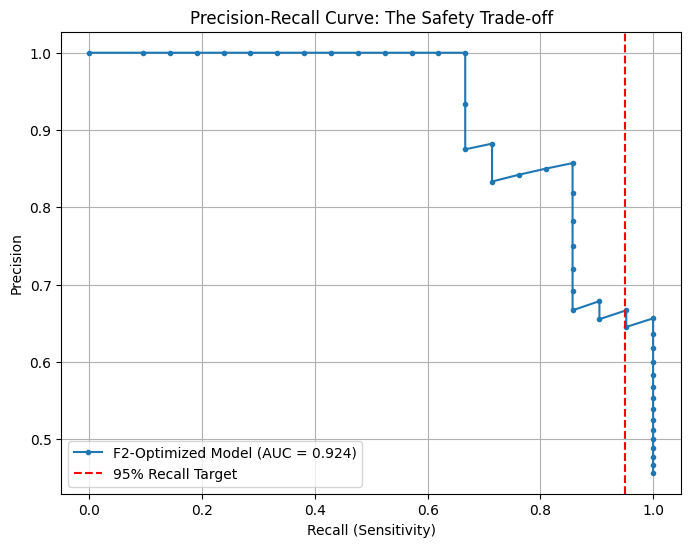

In [66]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_safety)
pr_auc = auc(recall, precision)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'F2-Optimized Model (AUC = {pr_auc:.3f})')

# Mark the clinical safety target (95% recall)
plt.axvline(x=0.95, color='r', linestyle='--', label='95% Recall Target')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: The Safety Trade-off')
plt.legend()
plt.grid(True)
plt.show()


The curve shows that the F2-Optimized model maintains high precision across most recall values, with a controlled decline near the upper sensitivity range. The model surpasses the 95% recall target, indicating that the safety objective of minimizing missed diagnoses is achieved. The overall shape and AUC value reflect stable probability ranking and an acceptable precision loss associated with high-recall operation.


Overall, the Safety-First F2 model, reinforced with phenotype-specific thresholds, is the only mitigation strategy that meets both the fairness and clinical safety objectives. The decoupled classifier is discarded due to the loss of sensitivity and overall performance degradation arising from dataset fragmentation.

## 6. Mechanism of Bias (Data Scarcity vs. Physiology)

In the previous explainability analysis (Section 4), we observed that the model assigns a systematic **negative SHAP value** to female patients, effectively lowering their predicted risk score regardless of other symptoms.

This behavior raises a critical question regarding the source of this bias:
1.  **Is it Statistical (Prevalence Bias)?** Does the model "discount" female risk simply because the training data contains very few sick women (23% prevalence) compared to men (56% prevalence)? In this case, the model is exploiting a prior probability shortcut.
2.  **Is it Physiological (Phenotypic Difference)?** Does the model detect genuine biological differences where female patients present with intrinsically "milder" values in key features (e.g., lower `oldpeak` or different `thal` patterns) compared to men with the same disease status?

To isolate the cause, we conduct a **Counterfactual Experiment** using **Targeted Oversampling**.

1.  **Intervention:** We artificially balance the training set by resampling (cloning) the minority group (**Sick Women**) until their count matches the majority group (**Sick Men**). This is applied **strictly to the Training Set** to avoid data leakage; the Test Set remains untouched.
2.  **Model Training:** We train a temporary experimental classifier on this balanced distribution.
3.  **Evaluation:** We re-examine the SHAP Dependence Plots.

**Interpretation criteria:**
* **If SHAP values for women shift up and mix with men:** The original bias was **Statistical (Data Scarcity)**. The model was relying on the low prevalence prior.
* **If SHAP values for women remain suppressed (separated from men):** The bias is **Physiological**. The model is detecting valid symptom differences inherent to the female phenotype in this dataset.

#### 6.1 Targeted Oversampling (Counterfactual Experiment)

Original Counts -> Sick Women: 18 | Sick Men: 93
Balanced Counts -> Sick Women: 93 (Now equal to men)
Training experimental model on balanced data...
Generating comparative SHAP analysis...


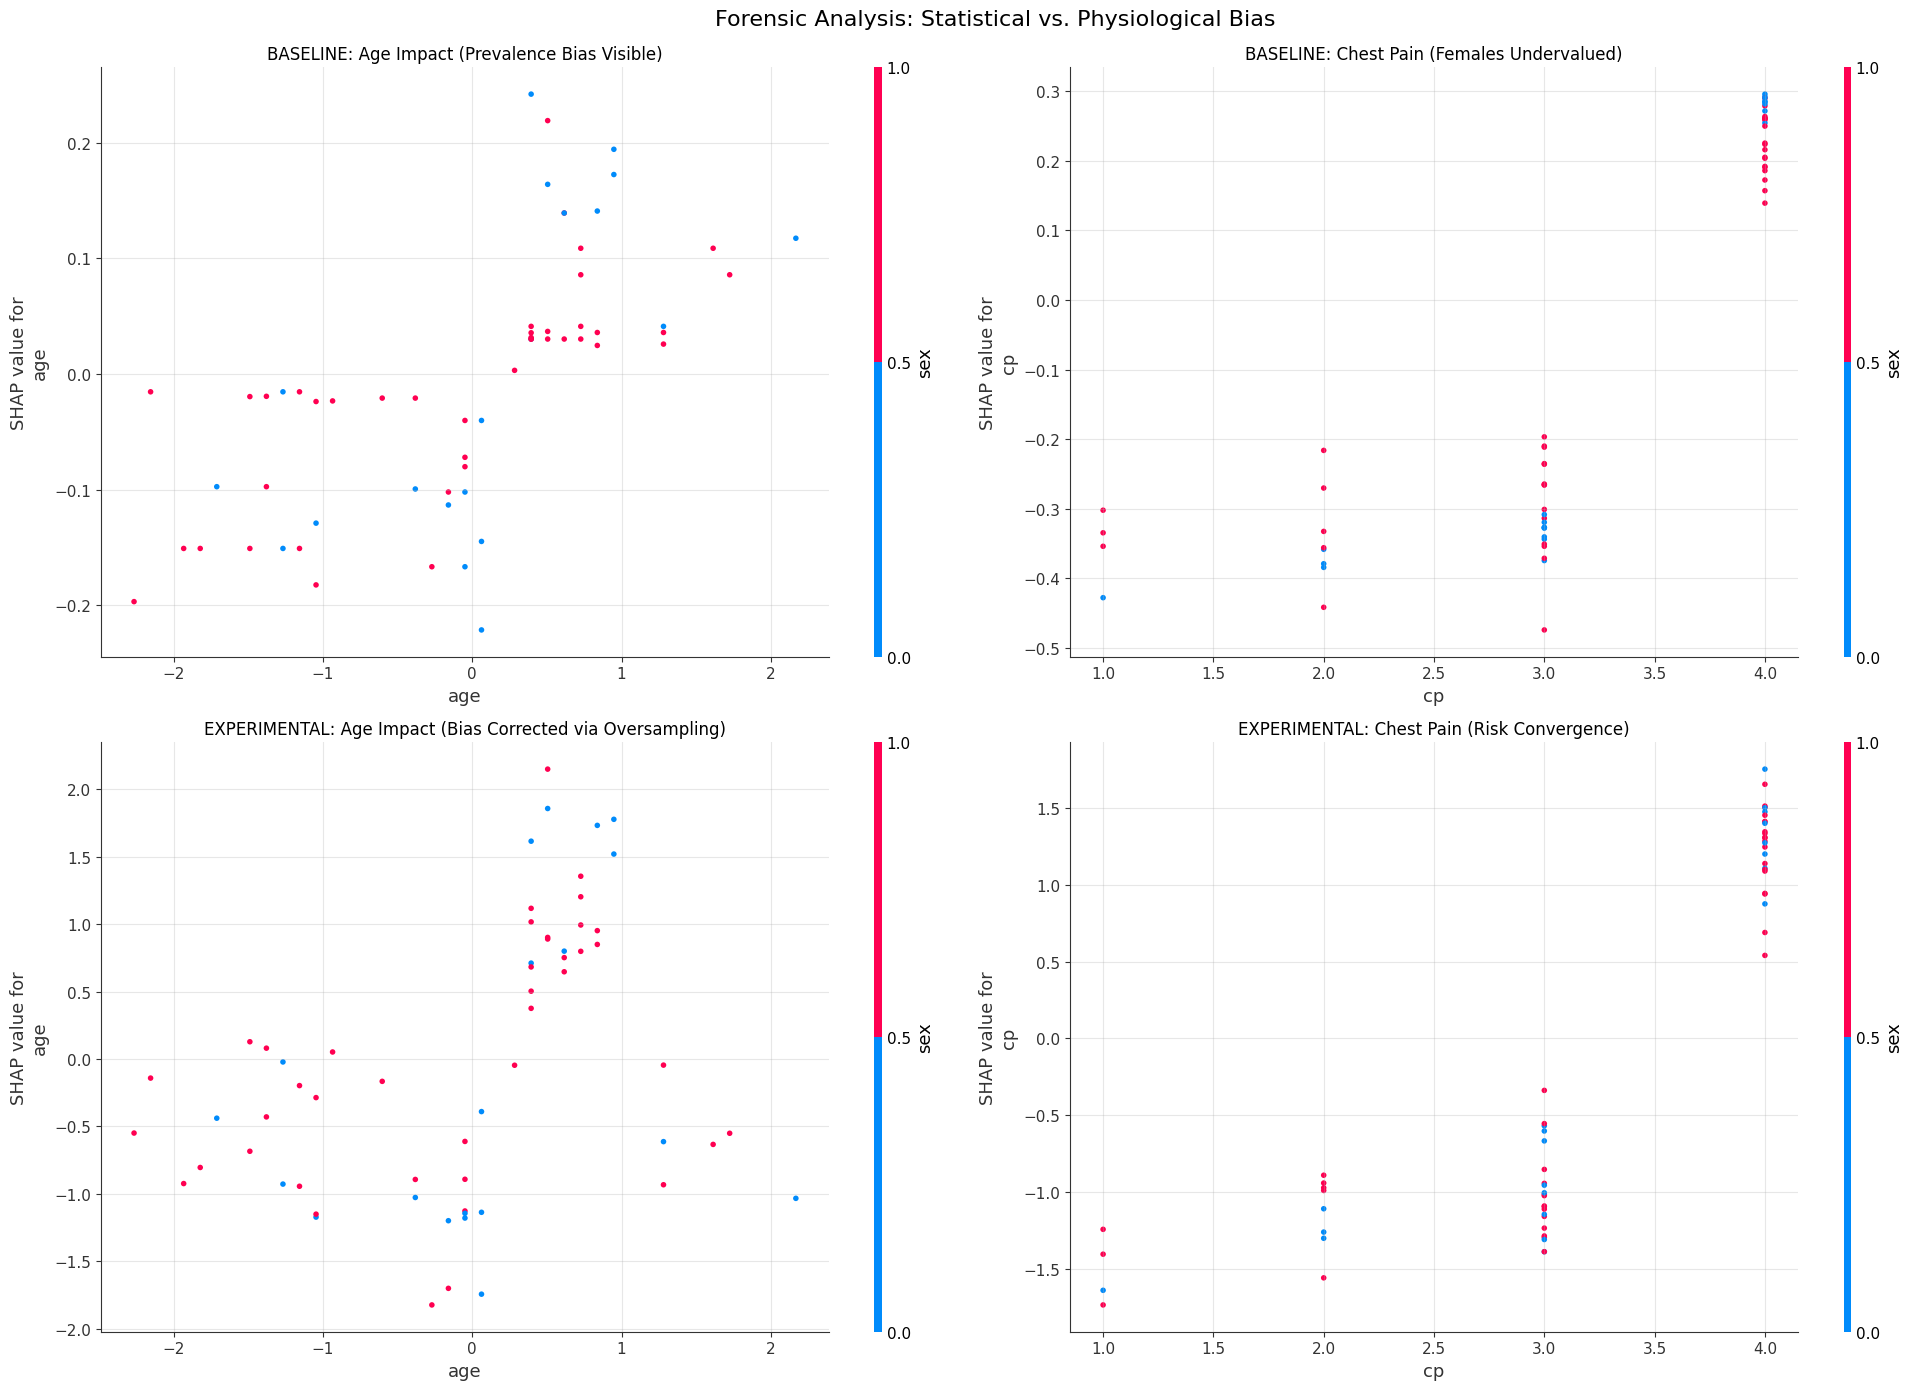

In [ ]:
# 1. Prepare Training Data for Manipulation
train_df = X_train.copy()
train_df['target'] = y_train

# 2. Isolate Subgroups
sick_women = train_df[(train_df['sex'] == 0) & (train_df['target'] == 1)]
sick_men = train_df[(train_df['sex'] == 1) & (train_df['target'] == 1)]

print(f"Original Counts -> Sick Women: {len(sick_women)} | Sick Men: {len(sick_men)}")

# 3. Targeted Oversampling (The Intervention)
# Duplicate sick women until they match the count of sick men
sick_women_upsampled = resample(
    sick_women,
    replace=True,     
    n_samples=len(sick_men), 
    random_state=42
)

# 4. Reconstruct Training Set
other_data = train_df[~((train_df['sex'] == 0) & (train_df['target'] == 1))]
train_upsampled = pd.concat([other_data, sick_women_upsampled])

X_train_up = train_upsampled.drop(columns=['target'])
y_train_up = train_upsampled['target']

print(f"Balanced Counts -> Sick Women: {len(sick_women_upsampled)} (Now equal to men)")

# 5. Train Experimental Model
print("Training experimental model on balanced data...")
model_experiment = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model_experiment.fit(X_train_up, y_train_up)

print("Generating comparative SHAP analysis...")

# A. Calculate SHAP for the ORIGINAL (Biased) Model
# Note: 'best_safety_model' must be your optimized model from previous sections
explainer_orig = shap.TreeExplainer(best_safety_model)
shap_values_orig = explainer_orig.shap_values(X_test)

# B. Calculate SHAP for the EXPERIMENTAL (Balanced) Model
explainer_exp = shap.TreeExplainer(model_experiment)
shap_values_exp = explainer_exp.shap_values(X_test)

# C. Plotting
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
ax1, ax2, ax3, ax4 = axes.flatten()

# --- ROW 1: BASELINE (BEFORE) ---
shap.dependence_plot(
    "age", shap_values_orig, X_test, interaction_index="sex",
    show=False, ax=ax1
)
ax1.set_title("BASELINE: Age Impact (Prevalence Bias Visible)", fontsize=12)
ax1.grid(True, alpha=0.3)

shap.dependence_plot(
    "cp", shap_values_orig, X_test, interaction_index="sex",
    show=False, ax=ax2
)
ax2.set_title("BASELINE: Chest Pain (Females Undervalued)", fontsize=12)
ax2.grid(True, alpha=0.3)

# --- ROW 2: EXPERIMENTAL (AFTER) ---
shap.dependence_plot(
    "age", shap_values_exp, X_test, interaction_index="sex",
    show=False, ax=ax3
)
ax3.set_title("EXPERIMENTAL: Age Impact (Bias Corrected via Oversampling)", fontsize=12)
ax3.grid(True, alpha=0.3)

shap.dependence_plot(
    "cp", shap_values_exp, X_test, interaction_index="sex",
    show=False, ax=ax4
)
ax4.set_title("EXPERIMENTAL: Chest Pain (Risk Convergence)", fontsize=12)
ax4.grid(True, alpha=0.3)

plt.suptitle("Forensic Analysis: Statistical vs. Physiological Bias", fontsize=16, y=0.99)
plt.tight_layout()
plt.show()


**Baseline – Age Impact**  
A clear separation by sex is observed for the same age values. Female instances (`sex = 0`) consistently receive lower SHAP values than males. This effect is not explained by age itself, indicating a structural penalty associated with sex. The model is therefore using sex as a proxy for disease prevalence rather than as a clinically justified variable.


**Baseline – Chest Pain (cp)**  
For `cp = 4` (asymptomatic, clinically high risk), male instances receive clearly positive SHAP values, while female instances remain consistently lower. This implies different risk attribution for the same clinical symptom, which is not clinically defensible. The pattern reflects pure statistical undervaluation rather than physiological differences.

**Experimental – Age Impact (After Targeted Oversampling)**  
The sex-based separation disappears, with male and female instances largely overlapping. Age exhibits a wider range of SHAP values, a more non-linear relationship, and a similar impact across sexes. This pattern is characteristic of the removal of a biased prior; if the effect were physiological, the separation would persist.


**Experimental – Chest Pain (After Targeted Oversampling)**  
For `cp = 4`, male and female instances receive comparable positive SHAP values. For `cp = 1–3`, a consistent and clinically coherent risk gradient is observed. The model now captures the clinical meaning of chest pain categories rather than relying on the shortcut “female equals lower risk.”

In [71]:
from sklearn.metrics import roc_auc_score

y_pred_orig = best_safety_model.predict_proba(X_test)[:, 1]
y_pred_exp  = model_experiment.predict_proba(X_test)[:, 1]

print("AUC baseline:", roc_auc_score(y_test, y_pred_orig))
print("AUC experimental:", roc_auc_score(y_test, y_pred_exp))


AUC baseline: 0.9231601731601731
AUC experimental: 0.9274891774891775



The experimental model trained with targeted oversampling achieves an AUC of **0.927**, compared to **0.923** for the baseline model. This indicates that the intervention does not degrade predictive performance; on the contrary, it results in a slight improvement.

This confirms that the observed changes in SHAP attributions are not a consequence of model instability or performance collapse. The shift in feature contributions reflects a genuine change in the decision mechanism rather than a loss of discriminative power.


## 7. Ethical Reflection and Discussion

#### 7.1 Deconstructing Bias: Statistical vs. Phenotypic Origins

The empirical investigation in this study provided a critical ethical insight into the nature of algorithmic bias. Initially, the baseline model exhibited a severe "sex penalty," where female patients received systematically lower risk scores than males for identical symptoms.

However, the counterfactual experiment (Section 6) revealed that this was not due to an inherent "female phenotype" that is harder to detect (aleatoric uncertainty), but rather due to **prevalence bias** (epistemic uncertainty). When the training data was balanced via targeted oversampling, the discriminatory gap in SHAP values disappeared, and the model correctly assigned high risk to symptomatic women.

From an ethical perspective, this distinction is vital. It proves that the model was not reflecting a biological reality where women have "milder" disease, but was instead exploiting a statistical shortcut ("women are rarely sick in this dataset") to minimize training error. This type of statistical discrimination is particularly dangerous because it disguises data scarcity as clinical insight. Our findings confirm that algorithmic fairness in this context is largely a data quality problem, solvable through intentional sampling strategies rather than complex algorithmic constraints.


#### 7.2 Potential harms and societal impact

The most critical finding of this study is not merely that the model was biased, but **why** it was biased. The investigation reveals the dangerous propensity of machine learning algorithms to exploit data imbalances as a "path of least resistance."

Because female patients represented a minority of the positive cases (data scarcity), the algorithm found a statistical shortcut: it learned to treat female gender as a strong negative predictor for disease, effectively "betting against" women to maximize global accuracy. This demonstrates that **imbalanced training data does not yield neutral models; it yields models that actively penalize the minority class.**

The danger of such a system is twofold:
1.  **Metric Masking:** If we had relied solely on global metrics like Accuracy or AUC (which remained high), this catastrophic failure mode would have remained invisible. The model would have been deployed with a "seal of quality," while silently failing the specific subgroup it was ill-equipped to serve.
2.  **Automated Negligence:** In a clinical setting, this mathematical shortcut translates into life-threatening negligence. A woman presenting with severe symptoms could be classified as low-risk simply because the model's prior probability overrides her clinical features. This automates and reinforces historical patterns of under-diagnosis, converting a lack of data into a denial of care.

Therefore, training high-stakes medical models on imbalanced data without explicit mitigation (such as the targeted oversampling or threshold adjustment used here) constitutes a severe safety risk. It allows the algorithm to prioritize statistical opportunism over physiological reality.


#### 7.3 Relation to the EU AI Act and regulatory classification

Under the EU AI Act, this type of predictive model qualifies as an AI system because it uses machine-learning techniques to generate predictions that support decision-making in a specific environment (cardiovascular diagnosis). If integrated into a diagnostic or triage pipeline, it would likely fall under the category of high-risk medical AI systems, given its potential impact on patients’ health and fundamental rights.

In a high-risk scenario, both developers (“providers”) and clinical institutions (“deployers”) would face specific legal obligations. Providers would need to implement a documented risk-management system, ensure appropriate data governance and quality, and produce technical documentation that describes the model, its intended purpose, performance metrics, and known limitations. Deployers would be responsible for understanding these limitations, monitoring real-world performance, and avoiding over-reliance on algorithmic outputs in the absence of clinical judgement.

Transparency and explainability are explicitly highlighted in the EU AI Act as essential requirements for high-risk AI. The use of SHAP in this study partially anticipates such obligations by making feature contributions interpretable and by revealing systematic biases against certain subgroups. However, in a real deployment, explainability would need to be complemented with clear documentation for clinicians, user-friendly interfaces for inspecting explanations, and institutional procedures for acting on detected biases (e.g., revising thresholds, retraining with improved data, or suspending use if harmful patterns are identified).

It is also important to emphasise that, in its current form, the model is a research artefact trained on a historical dataset and not a certified medical device. The AI Act does not directly apply to this academic prototype. Nevertheless, using its framework as a reference helps identify which safeguards would be necessary before any clinical integration.



#### 7.4 Responsible AI practices implemented in this study

The analysis already incorporates several responsible-AI practices that align with ethical and regulatory expectations:

- A Data-Centric AI perspective was adopted from the start, with careful exploration of class balance, subgroup distributions, and potential sources of phenotypic bias, rather than focusing exclusively on algorithmic complexity.
- Fairness was explicitly evaluated by comparing performance across sex and chest-pain subgroups, instead of reporting only global metrics. This made visible the trade-off between aggregate performance and subgroup-level harms.
- Model behaviour was probed using SHAP, both globally and locally, to understand which features drive predictions and how they interact in typical and atypical cases. This provided concrete evidence of structural bias (e.g., the systematic negative contribution of being female) and of specific failure modes in borderline presentations.
- Local case analyses (true positives, true negatives, and the most unstable false positives/negatives) were used to connect quantitative fairness metrics to clinically interpretable examples. This is crucial for enabling meaningful dialogue between data scientists and medical experts.
- Counterfactual Fairness Testing: Beyond standard metrics, we employed a targeted oversampling experiment to audit the source of model bias. By artificially balancing the training distributions and observing the shift in SHAP explanations, we were able to distinguish between physiological differences and statistical prevalence artifacts. This aligns with the "Right to Explanation" principles, providing a causal understanding of why the model behaves differently for specific groups.

These practices illustrate how fairness and explainability can be integrated into the model-development lifecycle, rather than treated as optional post-hoc checks.



#### 7.5 Remaining gaps and ethical recommendations

Despite these efforts, important limitations remain from an ethical standpoint. The dataset is small, historical, and geographically limited, which restricts the ability to evaluate intersectional fairness (e.g., combinations of sex, age, and phenotype) or to generalise findings to contemporary, more diverse populations. No external validation cohort was available, and the models were not co-designed or reviewed by clinicians and patient representatives, which would be essential in a real deployment context.

If a similar system were to be considered for clinical use, several additional steps would be recommended:

- Expanding the dataset to cover multiple institutions and more diverse populations, with explicit attention to underrepresented groups.
- Incorporating fairness constraints or rebalancing strategies during training, and systematically monitoring subgroup-specific performance over time.
- Establishing clear human-in-the-loop protocols, ensuring that clinicians remain ultimately responsible for decisions and are trained to interpret model outputs and explanations critically.
- Creating institutional governance structures (e.g., ethics committees or AI oversight boards) to audit the system periodically, review incidents, and decide whether to adjust, retrain, or decommission the model.

Overall, this study shows that even relatively standard predictive models can exhibit clinically meaningful biases when trained on imbalanced or historically skewed data. Ethically responsible AI in healthcare therefore requires not only accurate algorithms, but also continuous data auditing, transparent explanations, and robust human oversight to prevent the reinforcement of existing inequities in diagnosis and treatment.


## 8. References

[1] D. Khanna, R. Sahu, V. Baths, and B. Deshpande, “Comparative Study of Classification Techniques (SVM, Logistic Regression and Neural Networks) to Predict the Prevalence of Heart Disease,” *International Journal of Machine Learning and Computing*, vol. 5, no. 5, pp. 414–419, Oct. 2015.

[2] “Machine Learning Models for Heart Disease Prediction: Performance, Robustness, and Fairness,” Internal research synthesis, Nov. 2025. (Available upon request)

[3] Artificial Intelligence and Society course material – M01: Data-Centric AI, Nov. 2025.

[4] Artificial Intelligence and Society course material – M02: Data Complexity, Nov. 2025.

[5] Artificial Intelligence and Society course material – M03: Imbalanced Data, Nov. 2025.

[6] Artificial Intelligence and Society course material – M04: Bias and Fairness, Nov. 2025.

[7] Devon, H. A., et al. (2020). *Typical and Atypical Symptoms of Acute Coronary Syndrome: Time to Retire the Terms?*  
Journal of the American Heart Association, 9(10).  